# BÁO CÁO MACHINE LEARNING: PHÂN KHÚC KHÁCH HÀNG BÁN BUÔN BẰNG THUẬT TOÁN K-MEANS CLUSTERING

## 1. GIỚI THIỆU ĐỀ TÀI

### Bối cảnh bài toán
Trong lĩnh vực bán buôn (wholesale distribution), nhà phân phối cần hiểu rõ cấu trúc và hành vi tiêu dùng của từng nhóm khách hàng để đưa ra chiến lược kinh doanh phù hợp. Việc **phân khúc khách hàng (Customer Segmentation)** giúp:
- Tối ưu hóa chiến lược định giá và khuyến mãi theo từng nhóm.
- Cá nhân hóa dịch vụ và kế hoạch giao hàng dựa trên nhu cầu thực tế.
- Phát hiện các nhóm khách hàng tiềm năng chưa được khai thác.

### Mục tiêu bài toán
1. **Phân cụm không giám sát (Unsupervised Clustering)**: Áp dụng thuật toán **K-Means** để phân chia 440 khách hàng bán buôn thành các nhóm có hành vi tiêu dùng tương đồng.
2. **Xác định K tối ưu**: Sử dụng bộ ba chỉ số đánh giá — **Elbow Method (Inertia)**, **Silhouette Score** và **Davies-Bouldin Index** — để lựa chọn số cụm hợp lý nhất.
3. **Domain Feature Engineering**: Bổ sung các chỉ số phái sinh như tỷ lệ tươi sống, tỷ lệ hàng không thiết yếu và mức chi tiêu bình quân để tăng chất lượng phân cụm.
4. **Trực quan hóa 2D bằng PCA**: Chiếu không gian cao chiều về 2 chiều để quan sát phân bố cụm một cách trực quan.
5. **Phân tích đặc trưng từng cụm**: Giải thích ý nghĩa kinh doanh (business insight) của mỗi nhóm khách hàng phát hiện được.


---

### ĐỐI CHIẾU QUY TRÌNH 21 BƯỚC MÔ HÌNH MACHINE LEARNING CHUẨN

| STT | Bước Machine Learning | Mục thực hiện trong Notebook |
| :--- | :--- | :--- |
| 1 | Xác định bài toán (Problem Definition) | **Mục 1**: Phân khúc 440 khách hàng bán buôn ($K=3$) |
| 2 | Bản chất bài toán ML (Learning Paradigm) | **Mục 1 & 2**: Unsupervised Clustering không giám sát |
| 3 | Khảo sát lĩnh vực (Domain & Data Understanding) | **Mục 2 & 10**: Ngành bán buôn, 6 nhóm hàng, Kênh/Vùng |
| 4 | Khám phá & Xử lý dữ liệu (Data Exploration & Cleaning) | **Mục 4, 4e, 6**: Kiểm tra Null, Duplicates, Outlier IQR & **Biểu đồ thô** |
| 5 | Chuẩn hóa đặc trưng (Feature Scaling) | **Mục 5**: `StandardScaler` Z-score tự viết bằng Pure NumPy |
| 6 | Xử lý biến phân loại (Categorical Data & Encoding) | **Mục 5a & 10**: Tách `Channel`/`Region` để tránh nhiễu, dùng post-hoc test |
| 7 | Lựa chọn thuật toán & Loss Function | **Mục 8a, 8b**: K-Means, K-Means++, MiniBatch | Loss: Inertia WCSS |
| 8 | Kỹ thuật tạo đặc trưng (Feature Engineering) | **Mục 5b**: $\log(1+x)$ + 3 đặc trưng tỷ lệ chi tiêu tài chính |
| 9 | Chia dữ liệu & Kiểm soát Data Leakage | **Mục 8d**: Module `preprocess.py` & Train/Val Split chống rò rỉ |
| 10 | Lựa chọn phương pháp chia dữ liệu | **Mục 8d**: Out-of-Sample 80% Train / 20% Validation Split |
| 11 | Xây dựng mô hình cơ sở (Baseline Model) | **Mục 8b**: Standard K-Means khởi tạo ngẫu nhiên |
| 12 | Nguyên lý No Free Lunch | **Mục 8b**: So sánh 3 biến thể K-Means về thời gian & độ chính xác |
| 13 | Phân tích Bias & Variance | **Mục 8b, 8c**: Đồ thị hội tụ Inertia & 20-Seed Stability |
| 14 | Tối ưu siêu tham số (Hyperparameter Tuning) | **Mục 7**: Khảo sát $K \in [2, 8]$ bằng Elbow, Silhouette, DBI, CHI |
| 15 | Evaluation Metrics | **Mục 7, 8b**: Silhouette, CHI, DBI, Inertia, Min-Max Composite Score |
| 16 | Kiểm định chéo & Stability (Cross-Validation) | **Mục 8c**: 20-Seed Rand Index Stability Test (Mean = 0.9930) |
| 17 | Thực nghiệm huấn luyện mô hình | **Mục 8b**: Huấn luyện chuỗi nâng cấp 3 thuật toán |
| 18 | Kiểm định thống kê độ tin cậy | **Mục 9b**: Kiểm định Kruskal-Wallis (ANOVA non-parametric, $p < 0.001$) |
| 19 | Phân tích lỗi (Error Analysis) | **Mục 9c**: Trích xuất phân tích các điểm ranh giới ($s(i) < 0.05$) |
| 20 | Khả năng giải thích mô hình (Interpretability) | **Mục 8a, 9, 11**: Z-score Profile Table, PCA Biplot, Radar Chart |
| 21 | Chu trình lặp cải tiến mô hình (Iterative Development)| **Mục 8, 12**: Đóng gói `Pipeline`, `cluster_profiles.json`, `predict_new.py` |

---


## 2. GIỚI THIỆU DATASET

Bài toán sử dụng bộ dữ liệu chuẩn quốc tế từ thư viện UCI:
**UCI Machine Learning Repository – Wholesale Customers Data Set**
- **Link dataset**: https://archive.ics.uci.edu/dataset/292/wholesale+customers
- **Quy mô**: 440 khách hàng của nhà phân phối bán buôn tại Bồ Đào Nha.
- **Loại bài toán**: Phân cụm không giám sát (Unsupervised Clustering).

### Mô tả 8 biến đầu vào (Features):
1. **`Channel`**: Kênh bán hàng (1 = Khách sạn/Nhà hàng/Quán cà phê (HoReCa), 2 = Bán lẻ (Retail)).
2. **`Region`**: Vùng địa lý (1 = Lisbon, 2 = Oporto, 3 = Khác).
3. **`Fresh`**: Chi tiêu hàng năm cho sản phẩm tươi sống — đơn vị: monetary unit (m.u.).
4. **`Milk`**: Chi tiêu hàng năm cho sản phẩm sữa — m.u.
5. **`Grocery`**: Chi tiêu hàng năm cho hàng tạp hóa — m.u.
6. **`Frozen`**: Chi tiêu hàng năm cho sản phẩm đông lạnh — m.u.
7. **`Detergents_Paper`**: Chi tiêu hàng năm cho chất tẩy rửa & giấy — m.u.
8. **`Delicassen`**: Chi tiêu hàng năm cho thực phẩm cao cấp — m.u.


## 3. KHAI BÁO THƯ VIỆN & CẤU HÌNH HỆ THỐNG


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time

from model import StandardScaler, KMeans, KMeansPlusPlus, MiniBatchKMeans, PCA, silhouette_score, davies_bouldin_score, calinski_harabasz_score, Pipeline
from preprocess import build_features, FEATURE_COLS
import pickle

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("Đã tải thành công các thư viện Python!")


Đã tải thành công các thư viện Python!


## 4. ĐỌC DỮ LIỆU VÀO BỘ NHỚ VÀ HIỂN THỊ THÔNG SỐ


### 4a. Kích thước và chiều của dữ liệu


In [2]:
df = pd.read_csv('Wholesale_customers_data.csv')

print("=" * 50)
print("  KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU")
print("=" * 50)
print(f"  Số dòng (thực thể / khách hàng)  : {df.shape[0]:,}")
print(f"  Số cột (thuộc tính / đặc trưng)  : {df.shape[1]}")
print(f"  Số chiều (shape)                 : {df.shape}")
print()
print("--- 5 dòng đầu tiên ---")
print(df.head())


  KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU
  Số dòng (thực thể / khách hàng)  : 440
  Số cột (thuộc tính / đặc trưng)  : 8
  Số chiều (shape)                 : (440, 8)

--- 5 dòng đầu tiên ---
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


### 4b. Kiểu dữ liệu của các thuộc tính


In [3]:
print("=" * 50)
print("  KIỂU DỮ LIỆU CÁC THUỘC TÍNH")
print("=" * 50)
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"  {col:<22} | dtype: {str(df[col].dtype):<10} | Giá trị hợp lệ: {non_null}/{len(df)}")

print()
print("=" * 50)
print("  KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)")
print("=" * 50)
null_series = df.isnull().sum()
print(null_series.to_string())
print(f"=> Tổng số ô bị thiếu (missing values): {null_series.sum()} (Dữ liệu hoàn toàn sạch)")

print()
print("--- Thông tin tổng hợp (df.info()) ---")
buf = __import__('io').StringIO()
df.info(buf=buf)
print(buf.getvalue())


  KIỂU DỮ LIỆU CÁC THUỘC TÍNH
  Channel                | dtype: int64      | Giá trị hợp lệ: 440/440
  Region                 | dtype: int64      | Giá trị hợp lệ: 440/440
  Fresh                  | dtype: int64      | Giá trị hợp lệ: 440/440
  Milk                   | dtype: int64      | Giá trị hợp lệ: 440/440
  Grocery                | dtype: int64      | Giá trị hợp lệ: 440/440
  Frozen                 | dtype: int64      | Giá trị hợp lệ: 440/440
  Detergents_Paper       | dtype: int64      | Giá trị hợp lệ: 440/440
  Delicassen             | dtype: int64      | Giá trị hợp lệ: 440/440

  KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
=> Tổng số ô bị thiếu (missing values): 0 (Dữ liệu hoàn toàn sạch)

--- Thông tin tổng hợp (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (t

### 4c. Số lượng thực thể của các giá trị nhãn

Trong bộ dữ liệu này, hai cột có tính chất **nhãn / danh mục** là `Channel` (kênh bán hàng) và `Region` (vùng địa lý).


In [4]:
print("=" * 55)
print("  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: CHANNEL")
print("=" * 55)
channel_map = {1: 'HoReCa (Khách sạn/Nhà hàng)', 2: 'Retail (Bán lẻ)'}
ch_counts = df['Channel'].value_counts().sort_index()
for val, cnt in ch_counts.items():
    pct = cnt / len(df) * 100
    label = channel_map.get(val, f'Unknown ({val})')
    bar = '█' * int(pct / 2)
    print(f"  Channel {val} — {label:<30}: {cnt:>3} khách hàng ({pct:.1f}%) {bar}")

print()
print("=" * 55)
print("  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: REGION")
print("=" * 55)
region_map = {1: 'Lisbon', 2: 'Oporto', 3: 'Khác (Other)'}
rg_counts = df['Region'].value_counts().sort_index()
for val, cnt in rg_counts.items():
    pct = cnt / len(df) * 100
    label = region_map.get(val, f'Unknown ({val})')
    bar = '█' * int(pct / 2)
    print(f"  Region {val} — {label:<20}: {cnt:>3} khách hàng ({pct:.1f}%) {bar}")


  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: CHANNEL
  Channel 1 — HoReCa (Khách sạn/Nhà hàng)   : 298 khách hàng (67.7%) █████████████████████████████████
  Channel 2 — Retail (Bán lẻ)               : 142 khách hàng (32.3%) ████████████████

  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: REGION
  Region 1 — Lisbon              :  77 khách hàng (17.5%) ████████
  Region 2 — Oporto              :  47 khách hàng (10.7%) █████
  Region 3 — Khác (Other)        : 316 khách hàng (71.8%) ███████████████████████████████████


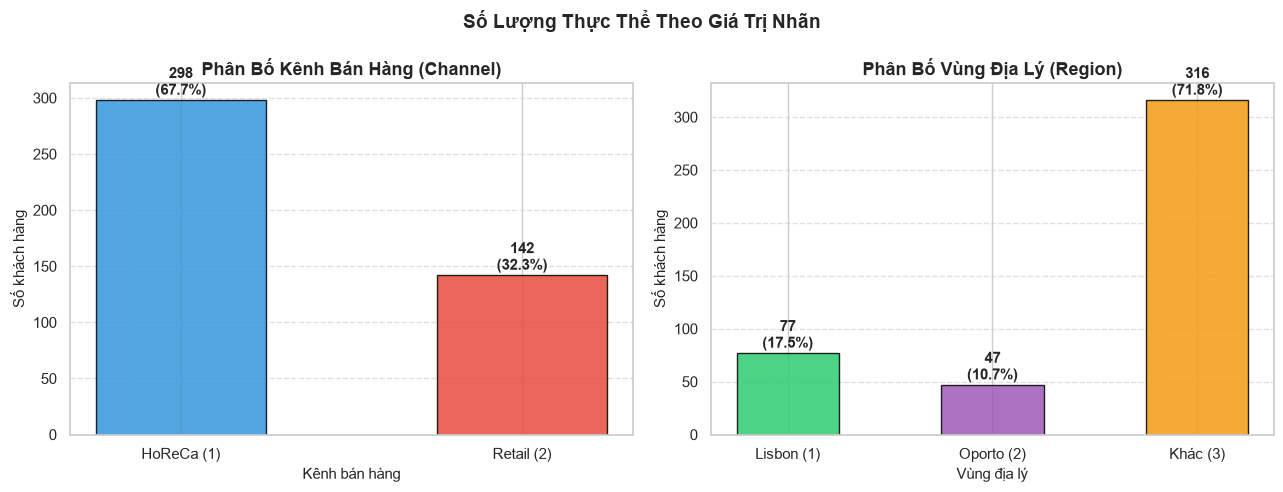

In [5]:
# Biểu đồ phân bố nhãn Channel và Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Channel
ch_labels = ['HoReCa (1)', 'Retail (2)']
ch_counts_list = [df[df['Channel'] == v].shape[0] for v in [1, 2]]
colors_ch = ['#3498db', '#e74c3c']
bars0 = axes[0].bar(ch_labels, ch_counts_list, color=colors_ch, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title('Phân Bố Kênh Bán Hàng (Channel)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kênh bán hàng', fontsize=11)
axes[0].set_ylabel('Số khách hàng', fontsize=11)
for bar in bars0:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}\n({h/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# Region
rg_labels = ['Lisbon (1)', 'Oporto (2)', 'Khác (3)']
rg_counts_list = [df[df['Region'] == v].shape[0] for v in [1, 2, 3]]
colors_rg = ['#2ecc71', '#9b59b6', '#f39c12']
bars1 = axes[1].bar(rg_labels, rg_counts_list, color=colors_rg, edgecolor='black', alpha=0.85, width=0.5)
axes[1].set_title('Phân Bố Vùng Địa Lý (Region)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vùng địa lý', fontsize=11)
axes[1].set_ylabel('Số khách hàng', fontsize=11)
for bar in bars1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}\n({h/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Số Lượng Thực Thể Theo Giá Trị Nhãn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4d. Giá trị lớn nhất, bé nhất và trung bình của các cột thuộc tính có giá trị số thực

Tất cả 8 cột đều có kiểu `int64` (số nguyên), nhưng đại diện cho giá trị tiền tệ — về bản chất là **số thực liên tục**. Dưới đây là thống kê mô tả chi tiết.


In [6]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
all_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print(f"  {'Thuộc tính':<22} | {'Min':>10} | {'Max':>12} | {'Mean':>12} | {'Std':>12}")
print("=" * 80)
for col in all_num_cols:
    mn  = df[col].min()
    mx  = df[col].max()
    avg = df[col].mean()
    std = df[col].std()
    print(f"  {col:<22} | {mn:>10,.0f} | {mx:>12,.0f} | {avg:>12,.2f} | {std:>12,.2f}")
print("=" * 80)

print()
print("--- Thống kê mô tả đầy đủ (df.describe()) ---")
print(df[spend_cols].describe().round(2).to_string())


  Thuộc tính             |        Min |          Max |         Mean |          Std
  Channel                |          1 |            2 |         1.32 |         0.47
  Region                 |          1 |            3 |         2.54 |         0.77
  Fresh                  |          3 |      112,151 |    12,000.30 |    12,647.33
  Milk                   |         55 |       73,498 |     5,796.27 |     7,380.38
  Grocery                |          3 |       92,780 |     7,951.28 |     9,503.16
  Frozen                 |         25 |       60,869 |     3,071.93 |     4,854.67
  Detergents_Paper       |          3 |       40,827 |     2,881.49 |     4,767.85
  Delicassen             |          3 |       47,943 |     1,524.87 |     2,820.11

--- Thống kê mô tả đầy đủ (df.describe()) ---
           Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
count     440.00    440.00    440.00    440.00            440.00      440.00
mean    12000.30   5796.27   7951.28   3071.93      

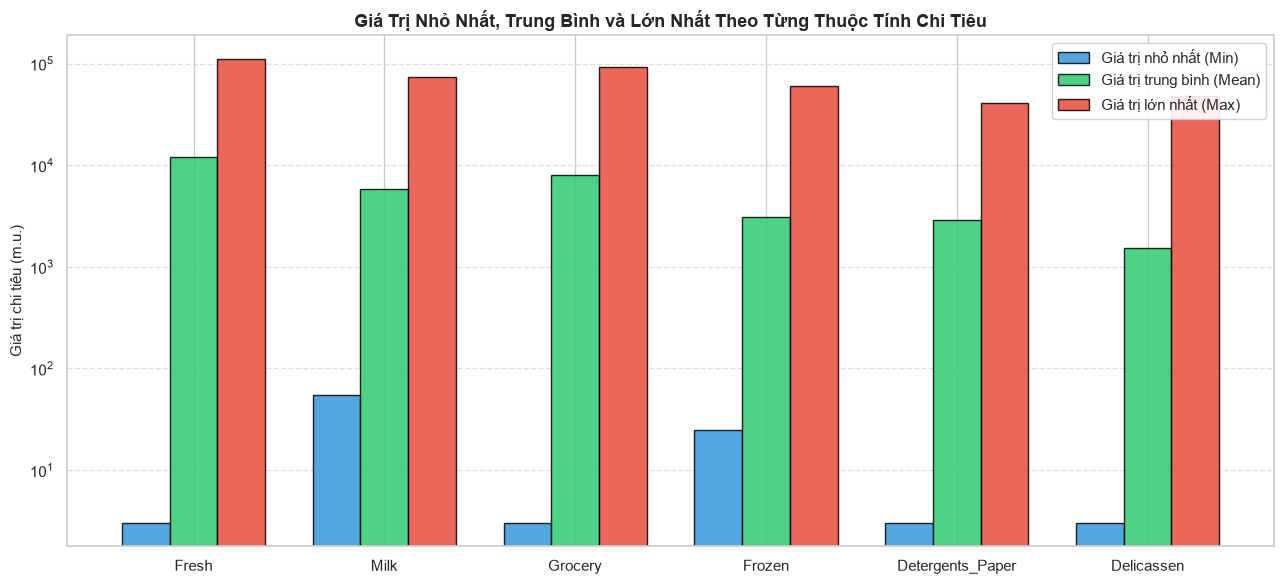

In [7]:
# Biểu đồ thống kê min/mean/max cho 6 biến chi tiêu
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
stats = pd.DataFrame({
    'Min': df[spend_cols].min(),
    'Mean': df[spend_cols].mean(),
    'Max': df[spend_cols].max()
})

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(spend_cols))
w = 0.25
colors_stat = ['#3498db', '#2ecc71', '#e74c3c']
labels_stat = ['Giá trị nhỏ nhất (Min)', 'Giá trị trung bình (Mean)', 'Giá trị lớn nhất (Max)']

for i, (col_stat, color, label) in enumerate(zip(['Min', 'Mean', 'Max'], colors_stat, labels_stat)):
    bars = ax.bar(x + (i - 1) * w, stats[col_stat], width=w, label=label,
                  color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(spend_cols, fontsize=11)
ax.set_title('Giá Trị Nhỏ Nhất, Trung Bình và Lớn Nhất Theo Từng Thuộc Tính Chi Tiêu', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị chi tiêu (m.u.)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_yscale('log')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 4e. KIỂM TRA OUTLIER TRÊN CÁC BIẾN CHI TIÊU

Đánh giá tỷ lệ và mức độ lệch của các giá trị ngoại lệ (outlier) bằng phương pháp khoảng tứ phân vị (IQR) trên 6 biến chi tiêu gốc.

  KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR)
            Biến  Số Outlier  % Outlier  Ngưỡng Dưới  Ngưỡng Trên
           Fresh          20        4.5     -17581.2      37642.8
            Milk          28        6.4      -6952.9      15676.1
         Grocery          24        5.5     -10601.1      23409.9
          Frozen          43        9.8      -3475.8       7772.2
Detergents_Paper          30        6.8      -5241.1       9419.9
      Delicassen          27        6.1      -1709.8       3938.2


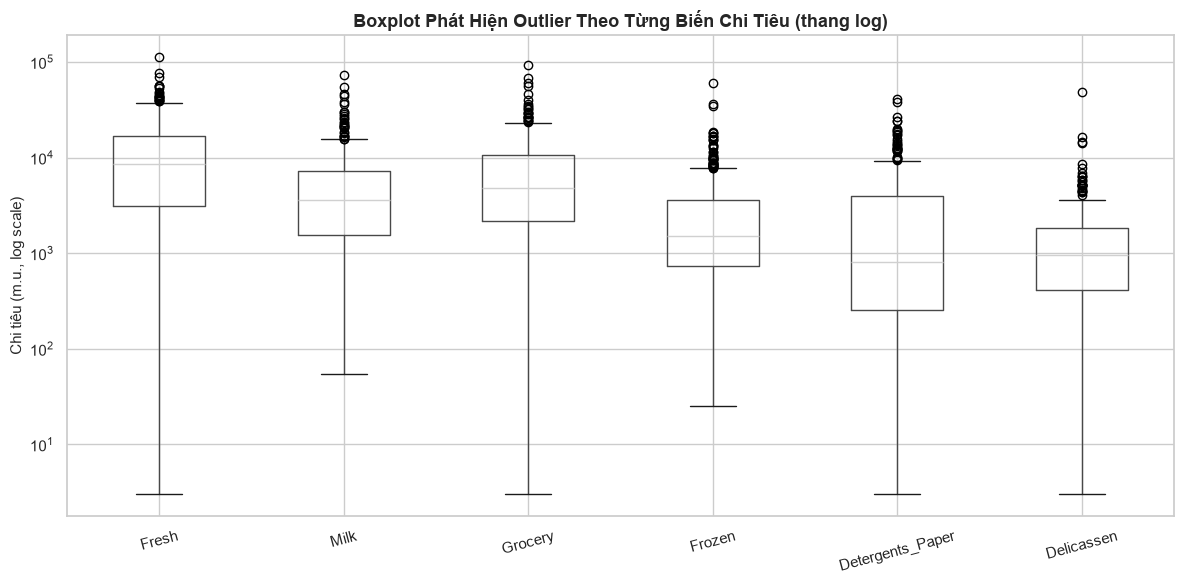


Nhận định: Tỷ lệ outlier khá cao ở hầu hết các biến — đây là đặc điểm TỰ NHIÊN
của dữ liệu chi tiêu doanh nghiệp (khách hàng lớn chi gấp hàng chục lần khách nhỏ),
KHÔNG phải lỗi nhập liệu. Quyết định: KHÔNG loại bỏ outlier, thay vào đó dùng
log1p-transform (đã áp dụng trong preprocess.py) để giảm ảnh hưởng đuôi dài (skewness)
thay vì cắt bỏ thông tin về nhóm khách hàng chi tiêu lớn — vốn là insight quan trọng.


In [8]:
print("=" * 60)
print("  KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR)")
print("=" * 60)

outlier_summary = []
for col in spend_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append([col, n_outliers, round(pct, 1), round(lower, 1), round(upper, 1)])

outlier_df = pd.DataFrame(outlier_summary, columns=['Biến', 'Số Outlier', '% Outlier', 'Ngưỡng Dưới', 'Ngưỡng Trên'])
print(outlier_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
df[spend_cols].boxplot(ax=ax)
ax.set_yscale('log')
ax.set_title('Boxplot Phát Hiện Outlier Theo Từng Biến Chi Tiêu (thang log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Chi tiêu (m.u., log scale)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nNhận định: Tỷ lệ outlier khá cao ở hầu hết các biến — đây là đặc điểm TỰ NHIÊN")
print("của dữ liệu chi tiêu doanh nghiệp (khách hàng lớn chi gấp hàng chục lần khách nhỏ),")
print("KHÔNG phải lỗi nhập liệu. Quyết định: KHÔNG loại bỏ outlier, thay vào đó dùng")
print("log1p-transform (đã áp dụng trong preprocess.py) để giảm ảnh hưởng đuôi dài (skewness)")
print("thay vì cắt bỏ thông tin về nhóm khách hàng chi tiêu lớn — vốn là insight quan trọng.")


## 5. TIỀN XỬ LÝ DỮ LIỆU VÀ TRỰC QUAN HÓA


### 5a. Kiểm tra và loại bỏ các cột không có ý nghĩa dự đoán

#### Phân tích từng cột:

| Cột | Loại | Quyết định | Lý do |
|-----|------|-----------|-------|
| `Channel` | Nhãn danh mục (1/2) | **Loại bỏ** | Là **biến nhãn ngữ cảnh** (metadata về kênh bán), không phải đặc trưng chi tiêu thực sự. Đưa vào clustering sẽ khiến mô hình phân cụm theo kênh thay vì hành vi tiêu dùng |
| `Region` | Nhãn danh mục (1/2/3) | **Loại bỏ** | Là **biến địa lý** (metadata vùng), không phản ánh hành vi chi tiêu. Đưa vào sẽ làm nhiễu phân cụm theo vị trí địa lý thay vì pattern tiêu dùng |
| `Fresh` đến `Delicassen` | Số thực (m.u.) | **Giữ lại** | Đây là **6 biến chi tiêu cốt lõi** — chứa thông tin trực tiếp về hành vi mua sắm của khách hàng |

#### Kết luận: Loại bỏ `Channel` và `Region`, giữ lại 6 biến chi tiêu cho phân cụm.


In [9]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print("=== TRƯỚC KHI LOẠI BỎ CỘT ===")
print(f"Các cột hiện có: {list(df.columns)}")
print(f"Số cột: {df.shape[1]}")

# Loại bỏ Channel và Region
df_clean = df[spend_cols].copy()

print()
print("=== SAU KHI LOẠI BỎ Channel VÀ Region ===")
print(f"Các cột còn lại: {list(df_clean.columns)}")
print(f"Số cột: {df_clean.shape[1]}")
print(f"Kích thước tập dữ liệu: {df_clean.shape}")
print()
print("Lý do loại bỏ:")
print("  - Channel: Là nhãn kênh bán (HoReCa/Retail) — metadata, không phải hành vi chi tiêu.")
print("  - Region : Là nhãn vùng địa lý (Lisbon/Oporto/Khác) — metadata vị trí.")
print("  => Giữ nguyên 6 biến chi tiêu để phân cụm theo hành vi thực sự.")


=== TRƯỚC KHI LOẠI BỎ CỘT ===
Các cột hiện có: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Số cột: 8

=== SAU KHI LOẠI BỎ Channel VÀ Region ===
Các cột còn lại: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Số cột: 6
Kích thước tập dữ liệu: (440, 6)

Lý do loại bỏ:
  - Channel: Là nhãn kênh bán (HoReCa/Retail) — metadata, không phải hành vi chi tiêu.
  - Region : Là nhãn vùng địa lý (Lisbon/Oporto/Khác) — metadata vị trí.
  => Giữ nguyên 6 biến chi tiêu để phân cụm theo hành vi thực sự.


### 5b. Chuyển tất cả thuộc tính về dạng số

#### Vấn đề:
Các biến chi tiêu (`Fresh`, `Milk`, ...) có **phân bố lệch phải rất mạnh** (right-skewed) với nhiều outlier cực đại. K-Means dùng khoảng cách Euclidean nên rất nhạy cảm với outlier và phân bố không đồng đều.

#### Giải pháp — 3 bước biến đổi:

**Bước 1 — Log Transform (`log1p`)**: Áp dụng `log(x + 1)` lên toàn bộ 6 biến chi tiêu:
- Triệt tiêu ảnh hưởng của outlier (khách hàng chi tiêu cực lớn)
- Đưa phân bố lệch phải về dạng gần chuẩn (symmetric)
- `log1p` thay vì `log` để xử lý an toàn khi có giá trị = 0

**Bước 2 — Feature Engineering (Biến phái sinh tỷ lệ)**:
- `Fresh_Ratio` = Fresh / Total_Spend → tỷ lệ hàng tươi sống (phân biệt HoReCa vs Retail)
- `NonEssential_Ratio` = (Frozen + Delicassen) / Total_Spend → mức "cao cấp"
- `Grocery_Milk_Ratio` = Grocery / (Milk + 1) → hành vi mua sắm tạp hóa

**Bước 3 — StandardScaler**: Chuẩn hóa về phân bố μ=0, σ=1 để các biến có đơn vị khác nhau đóng góp đều nhau vào khoảng cách.


In [10]:
# spend_cols = 6 cột chi tiêu GỐC để vẽ biểu đồ phân bố / boxplot / correlation thô
# FEATURE_COLS (từ preprocess.py) = 9 cột đặc trưng đã biến đổi dùng cho K-Means
# Hai biến KHÁC NHAU — không được dùng lẫn lộn.
spend_cols = FEATURE_COLS

# ─── Luồng 1: Tiền xử lý chuẩn tập trung dùng cho K-Means clustering (X_scaled) ───
df_feat_only = build_features(df)  # 9 cột: 6 log_col + 3 ratio_log
feat_cols = list(df_feat_only.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat_only.values)

print("=== LUỒNG 1: TIỀN XỬ LÝ CHUẨN CỦA PREPROCESS.PY (DÀNH CHO K-MEANS) ===")
print(f"Số features input K-Means: {len(feat_cols)} -> {feat_cols}")
print(f"Kích thước X_scaled: {X_scaled.shape}")

# ─── Luồng 2: Biến thô & tỷ lệ trực quan hóa dành cho Profiling (df_feat) ───
# LƯU Ý: Các cột trong df_feat dưới đây chỉ dùng để trực quan hóa kinh doanh ở Cell 36-42, KHÔNG dùng làm input cho K-Means.
df_feat = df.copy()
df_feat['Total_Spend'] = df_feat[spend_cols].sum(axis=1)
df_feat['Fresh_Ratio'] = df_feat['Fresh'] / (df_feat['Total_Spend'] + 1e-6)
df_feat['NonEssential_Ratio'] = (df_feat['Frozen'] + df_feat['Delicassen']) / (df_feat['Total_Spend'] + 1e-6)
df_feat['Grocery_Milk_Ratio'] = df_feat['Grocery'] / (df_feat['Milk'] + 1e-6)
for col in spend_cols:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])

print("\n=== LUỒNG 2: ĐẶC TRƯNG PHỤC VỤ TRỰC QUAN HÓA KINH DOANH (CELL 36-42) ===")
new_feats = ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']
print(f"Đã tạo các biến trực quan hóa: {new_feats}")


=== LUỒNG 1: TIỀN XỬ LÝ CHUẨN CỦA PREPROCESS.PY (DÀNH CHO K-MEANS) ===
Số features input K-Means: 9 -> ['Fresh_log', 'Milk_log', 'Grocery_log', 'Frozen_log', 'Detergents_Paper_log', 'Delicassen_log', 'Fresh_Ratio_log', 'NonEssential_Ratio_log', 'Grocery_Milk_Ratio_log']
Kích thước X_scaled: (440, 9)

=== LUỒNG 2: ĐẶC TRƯNG PHỤC VỤ TRỰC QUAN HÓA KINH DOANH (CELL 36-42) ===
Đã tạo các biến trực quan hóa: ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']


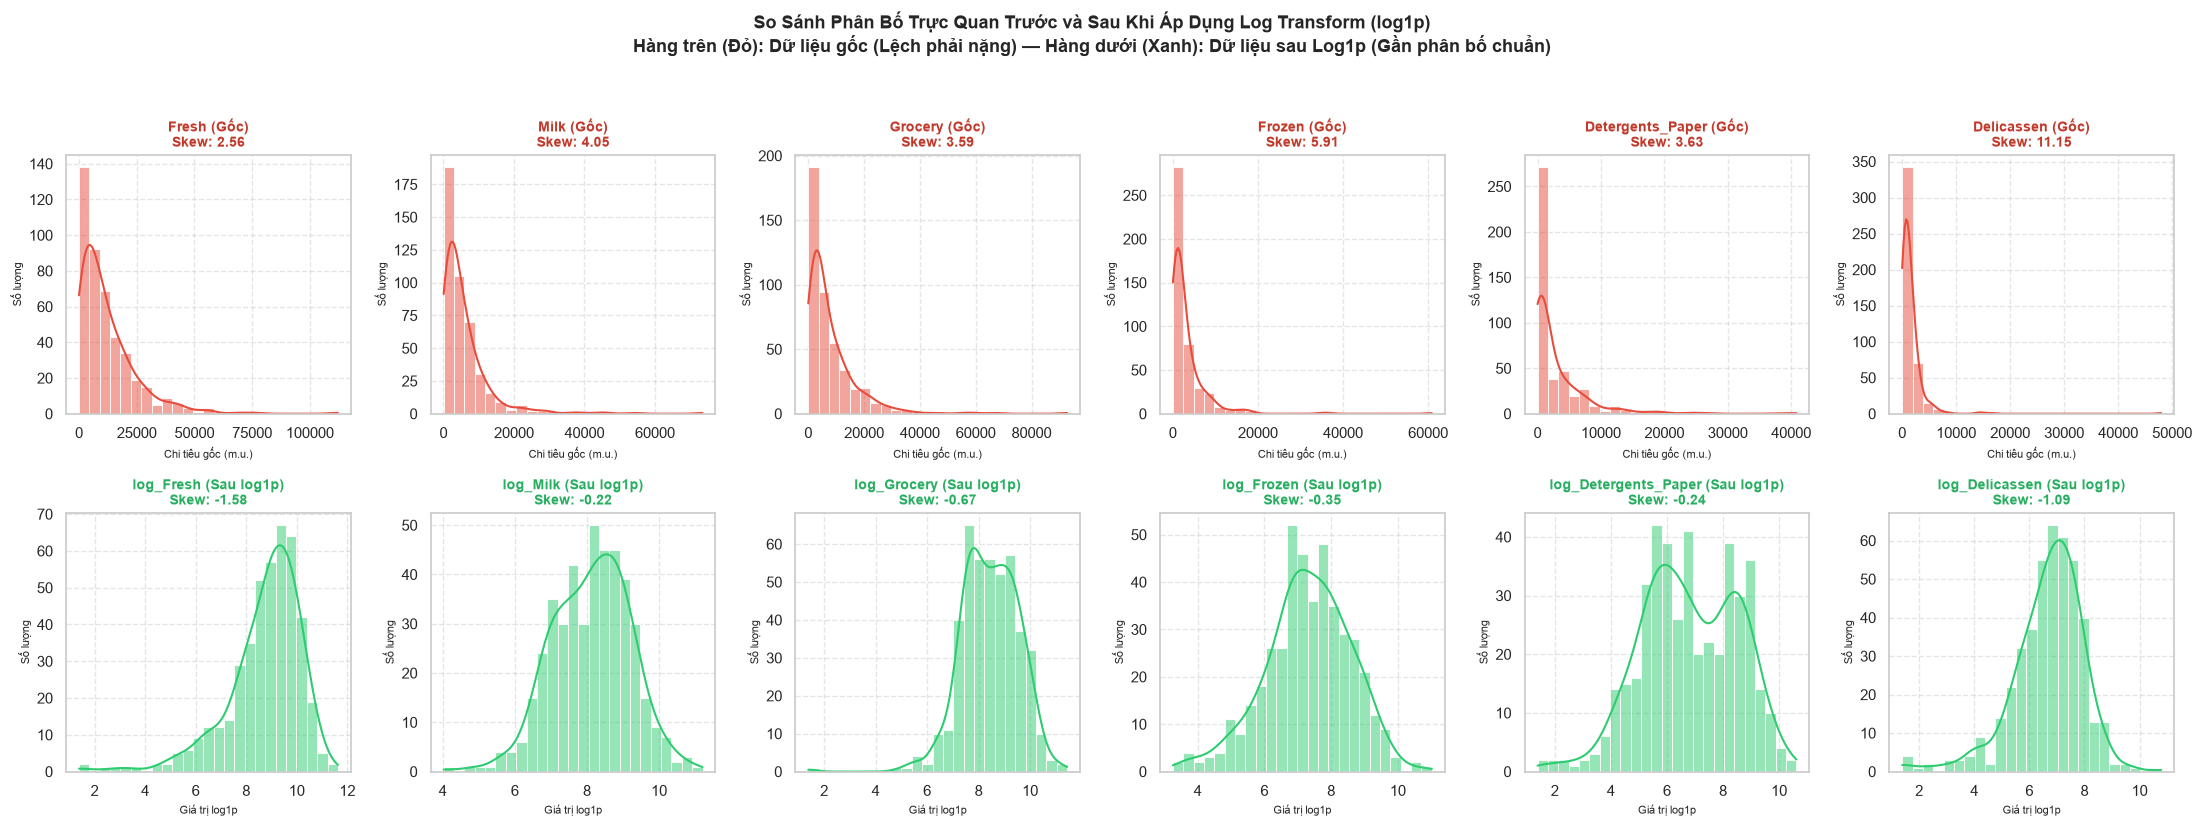

Nhận xét kỹ thuật:
  • Fresh             : Skewness gốc =   2.56 (Lệch phải)  -->  Sau log1p =  -1.58 (Cân bằng)
  • Milk              : Skewness gốc =   4.05 (Lệch phải)  -->  Sau log1p =  -0.22 (Cân bằng)
  • Grocery           : Skewness gốc =   3.59 (Lệch phải)  -->  Sau log1p =  -0.67 (Cân bằng)
  • Frozen            : Skewness gốc =   5.91 (Lệch phải)  -->  Sau log1p =  -0.35 (Cân bằng)
  • Detergents_Paper  : Skewness gốc =   3.63 (Lệch phải)  -->  Sau log1p =  -0.24 (Cân bằng)
  • Delicassen        : Skewness gốc =  11.15 (Lệch phải)  -->  Sau log1p =  -1.09 (Cân bằng)


In [11]:
# So sánh phân bố trước và sau log transform (Trực quan hóa chuẩn xác 2 hàng)
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
colors_before = '#e74c3c'
colors_after  = '#2ecc71'

for i, col in enumerate(spend_cols):
    skew_before = df_clean[col].skew()
    skew_after  = df_feat[f'log_{col}'].skew()
    
    # Hàng 1: Phân bố gốc (Gốc)
    ax_top = axes[0, i]
    sns.histplot(df_clean[col], kde=True, ax=ax_top, color=colors_before, bins=25)
    ax_top.set_title(f'{col} (Gốc)\nSkew: {skew_before:.2f}', fontsize=10, fontweight='bold', color='#c0392b')
    ax_top.set_xlabel('Chi tiêu gốc (m.u.)', fontsize=8)
    ax_top.set_ylabel('Số lượng', fontsize=8)
    ax_top.grid(True, linestyle='--', alpha=0.5)
    
    # Hàng 2: Phân bố sau log1p
    ax_bottom = axes[1, i]
    sns.histplot(df_feat[f'log_{col}'], kde=True, ax=ax_bottom, color=colors_after, bins=25)
    ax_bottom.set_title(f'log_{col} (Sau log1p)\nSkew: {skew_after:.2f}', fontsize=10, fontweight='bold', color='#27ae60')
    ax_bottom.set_xlabel('Giá trị log1p', fontsize=8)
    ax_bottom.set_ylabel('Số lượng', fontsize=8)
    ax_bottom.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So Sánh Phân Bố Trực Quan Trước và Sau Khi Áp Dụng Log Transform (log1p)\n'
             'Hàng trên (Đỏ): Dữ liệu gốc (Lệch phải nặng) — Hàng dưới (Xanh): Dữ liệu sau Log1p (Gần phân bố chuẩn)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Nhận xét kỹ thuật:")
for col in spend_cols:
    sb = df_clean[col].skew()
    sa = df_feat[f'log_{col}'].skew()
    print(f"  • {col:<18}: Skewness gốc = {sb:>6.2f} (Lệch phải)  -->  Sau log1p = {sa:>6.2f} (Cân bằng)")


### Minh họa bảng dữ liệu sau tiền xử lý (không ghi đè file)

Bảng dưới đây minh họa đầy đủ các biến phái sinh (log-transform, tỷ lệ chi tiêu) cho mục đích 
trình bày trong notebook. **File `wholesale_preprocessed.csv` chính thức nộp bài do `main.py` 
xuất ra** (chỉ gồm dữ liệu gốc + cột `Cluster`) — notebook không ghi đè file này.

In [12]:
# ─── Đồng bộ nhãn cụm từ Pipeline (reproducible) ───────────────────────────
# Chiến lược: Nếu kmeans_pipeline.pkl đã tồn tại (từ main.py) thì load đòn bẩy nhãn,
# nếu chưa có thì tự động huấn luyện 3 thuật toán & chọn mô hình xuất sắc nhất.
import os
from model import Pipeline, select_best_algorithm, KMeans, KMeansPlusPlus, MiniBatchKMeans, map_cluster_profiles
import json

if os.path.exists('kmeans_pipeline.pkl'):
    pipeline = Pipeline.load('kmeans_pipeline.pkl')
    cluster_labels = pipeline.predict(X_scaled)
    best_model = pipeline.steps[-1][1]
    best_model_class = type(best_model)
    print('[Reproducibility] Đã nạp nhãn cụm từ kmeans_pipeline.pkl thành công.')
else:
    print('[Reproducibility] Chưa có file pkl -> Tiến hành huấn luyện 3 thuật toán & chọn mô hình tốt nhất...')
    algorithms_fallback = {
        'KMeans (Random Init)': KMeans(n_clusters=3, n_init=10, random_state=42),
        'KMeans++ (D^2+Oversampling)': KMeansPlusPlus(n_clusters=3, n_init=10, random_state=42, oversample_factor=3),
        'MiniBatchKMeans (Online)': MiniBatchKMeans(n_clusters=3, n_init=10, random_state=42, batch_size=100, max_no_improvement=15),
    }
    results_fb = {}
    for name_fb, model_fb in algorithms_fallback.items():
        lbl_fb = model_fb.fit_predict(X_scaled)
        results_fb[name_fb] = {
            'model': model_fb,
            'model_class': type(model_fb),
            'labels': lbl_fb,
            'silhouette': silhouette_score(X_scaled, lbl_fb),
            'calinski': calinski_harabasz_score(X_scaled, lbl_fb),
            'davies': davies_bouldin_score(X_scaled, lbl_fb),
        }
    best_key_fb, _ = select_best_algorithm(results_fb)
    best_model = results_fb[best_key_fb]['model']
    best_model_class = results_fb[best_key_fb]['model_class']
    cluster_labels = results_fb[best_key_fb]['labels']
    pipeline = Pipeline([('scaler', scaler), ('kmeans', best_model)])
    pipeline.save('kmeans_pipeline.pkl')
    profiles_fb = map_cluster_profiles(df, cluster_labels)
    with open('cluster_profiles.json', 'w', encoding='utf-8') as f:
        json.dump({str(k): v for k, v in profiles_fb.items()}, f, ensure_ascii=False, indent=2)

df['Cluster'] = cluster_labels
df_feat['Cluster'] = cluster_labels


=== BẢNG DỮ LIỆU TIỀN XỬ LÝ ĐẦY ĐỦ (CHỈ HIỂN THỊ, KHÔNG GHI FILE) ===
Kích thước   : 440 dòng × 12 cột
Nguồn nhãn   : kmeans_pipeline.pkl (do main.py xuất ra)

Danh sách cột:
   1. Channel                        | int64 ← Gốc (bị loại khi clustering)
   2. Region                         | int64 ← Gốc (bị loại khi clustering)
   3. Fresh_log                      | float64 ← Khớp preprocess.py
   4. Milk_log                       | float64 ← Khớp preprocess.py
   5. Grocery_log                    | float64 ← Khớp preprocess.py
   6. Frozen_log                     | float64 ← Khớp preprocess.py
   7. Detergents_Paper_log           | float64 ← Khớp preprocess.py
   8. Delicassen_log                 | float64 ← Khớp preprocess.py
   9. Fresh_Ratio_log                | float64 ← Khớp preprocess.py
  10. NonEssential_Ratio_log         | float64 ← Khớp preprocess.py
  11. Grocery_Milk_Ratio_log         | float64 ← Khớp preprocess.py
  12. Cluster                        | int64 ← CỘT NHÃN CUỐI


### 5c. Thu giảm số chiều và hiển thị trên không gian 2D

Sử dụng **Principal Component Analysis (PCA)** để chiếu không gian {n} chiều về **2 chiều (2D)** nhằm trực quan hóa phân bố cụm. Mỗi cụm (nhãn) được biểu diễn bằng **màu sắc khác nhau**.

> **Lưu ý**: Cột nhãn là cột **cuối cùng** trong tập dữ liệu tiền xử lý (`Cluster`).


=== THU GIẢM SỐ CHIỀU BẰNG PCA ===
Số chiều ban đầu       : 9 chiều
Số chiều sau PCA       : 2 chiều
PC1 giải thích phương sai: 45.11%
PC2 giải thích phương sai: 22.35%
Tổng phương sai giữ lại  : 67.45%


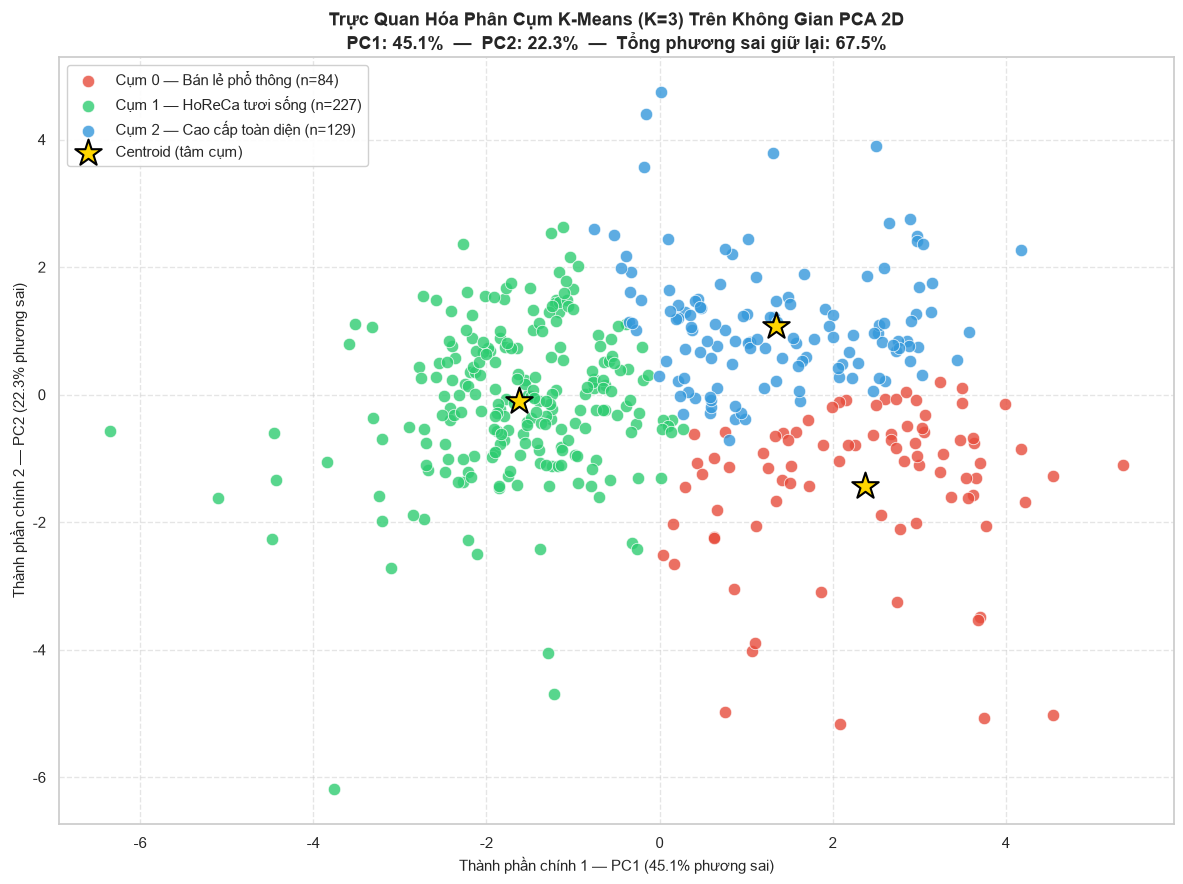

In [13]:
# PCA 2 chiều
pca = PCA(n_components=2)  # SVD-based PCA là tất định, không cần random_state
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

# cluster_labels đã được định nghĩa  # nhãn từ K-Means (cột cuối trong file tiền xử lý)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

centers_pca = pca.transform(best_model.cluster_centers_)

print("=== THU GIẢM SỐ CHIỀU BẰNG PCA ===")
print(f"Số chiều ban đầu       : {X_scaled.shape[1]} chiều")
print(f"Số chiều sau PCA       : 2 chiều")
print(f"PC1 giải thích phương sai: {var_explained[0]:.2f}%")
print(f"PC2 giải thích phương sai: {var_explained[1]:.2f}%")
print(f"Tổng phương sai giữ lại  : {sum(var_explained):.2f}%")

palette = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
cluster_names = {0: 'Cụm 0 — Bán lẻ phổ thông', 1: 'Cụm 1 — HoReCa tươi sống', 2: 'Cụm 2 — Cao cấp toàn diện'}

fig, ax = plt.subplots(figsize=(12, 9))
for cid in sorted(df_pca['Cluster'].unique()):
    mask = df_pca['Cluster'] == cid
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               color=palette[cid],
               label=f'{cluster_names[cid]} (n={mask.sum()})',
               alpha=0.80, s=80, edgecolors='white', linewidth=0.6)

# Vẽ centroid
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           marker='*', s=400, color='gold', edgecolors='black',
           linewidth=1.5, zorder=6, label='Centroid (tâm cụm)')

ax.set_title(
    f'Trực Quan Hóa Phân Cụm K-Means (K=3) Trên Không Gian PCA 2D\n'
    f'PC1: {var_explained[0]:.1f}%  —  PC2: {var_explained[1]:.1f}%  —  '
    f'Tổng phương sai giữ lại: {sum(var_explained):.1f}%',
    fontsize=13, fontweight='bold')
ax.set_xlabel(f'Thành phần chính 1 — PC1 ({var_explained[0]:.1f}% phương sai)', fontsize=11)
ax.set_ylabel(f'Thành phần chính 2 — PC2 ({var_explained[1]:.1f}% phương sai)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.92, loc='best')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


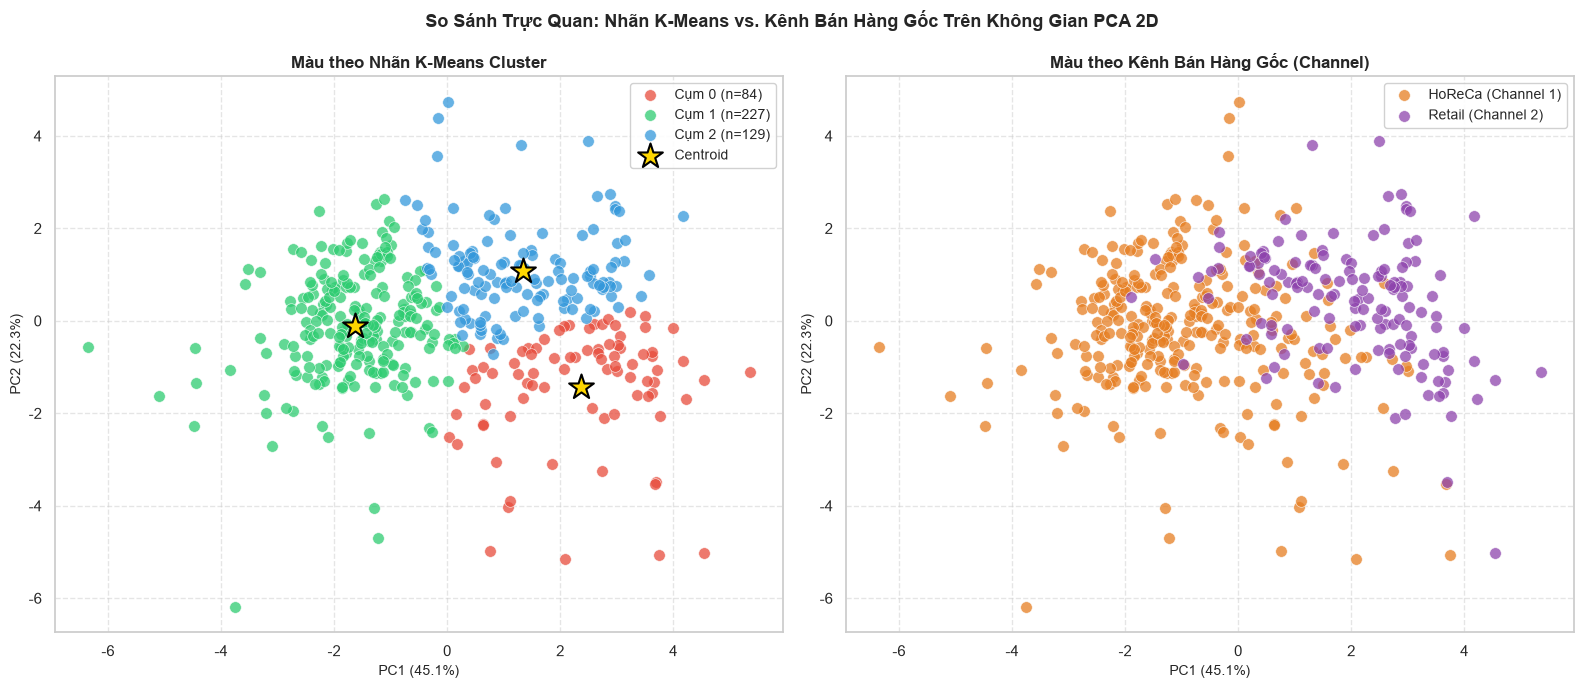

Nhận xét: Cụm K-Means không hoàn toàn trùng khớp với Channel gốc,
vì K-Means phân cụm theo hành vi CHI TIÊU, còn Channel là phân loại kênh bán hàng.


In [14]:
# Biểu đồ bổ sung: PCA với màu theo Channel gốc (để đối chiếu)
channel_map_label = {1: 'HoReCa (Channel 1)', 2: 'Retail (Channel 2)'}
palette_ch = {1: '#e67e22', 2: '#8e44ad'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Trái: màu theo Cluster (K-Means)
for cid in sorted(df_pca['Cluster'].unique()):
    mask = df_pca['Cluster'] == cid
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    color=palette[cid], label=f'Cụm {cid} (n={mask.sum()})',
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], marker='*', s=350,
                color='gold', edgecolors='black', linewidth=1.5, zorder=5, label='Centroid')
axes[0].set_title('Màu theo Nhãn K-Means Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=10)
axes[0].legend(fontsize=10, framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Phải: màu theo Channel gốc
for ch_val, ch_name in channel_map_label.items():
    mask_ch = df['Channel'] == ch_val
    axes[1].scatter(X_pca[mask_ch.values, 0], X_pca[mask_ch.values, 1],
                    color=palette_ch[ch_val], label=ch_name,
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
axes[1].set_title('Màu theo Kênh Bán Hàng Gốc (Channel)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=10)
axes[1].legend(fontsize=10, framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So Sánh Trực Quan: Nhãn K-Means vs. Kênh Bán Hàng Gốc Trên Không Gian PCA 2D',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét: Cụm K-Means không hoàn toàn trùng khớp với Channel gốc,")
print("vì K-Means phân cụm theo hành vi CHI TIÊU, còn Channel là phân loại kênh bán hàng.")


## 6. KHÁM PHÁ DỮ LIỆU TRỰC QUAN (EDA)

Kiểm tra phân bố và mối tương quan giữa các biến chi tiêu.


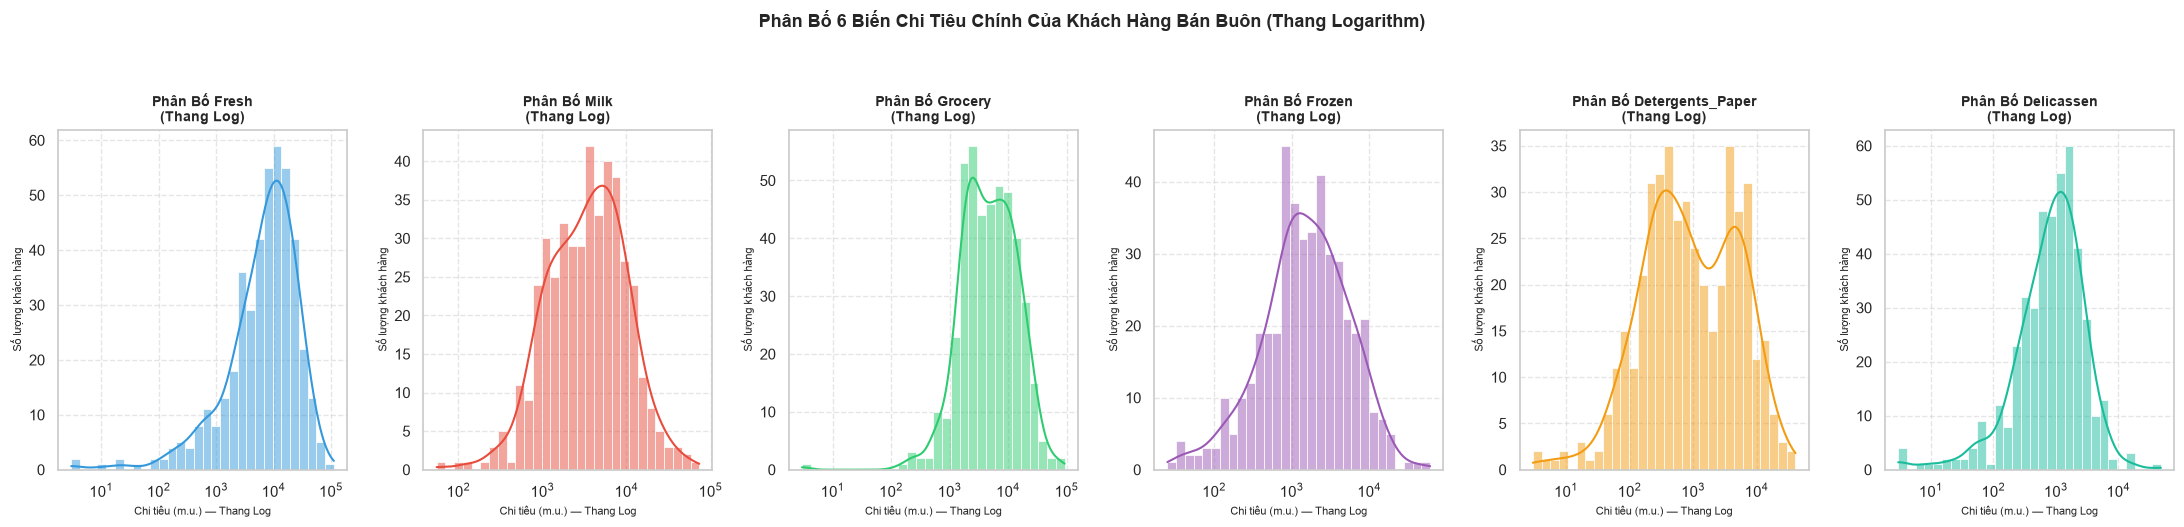

In [15]:
# Histogram phân bố 6 biến chi tiêu DỮ LIỆU THÔ GỐC (Thang đo tuyến tính m.u.)
colors_dist = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (col, color) in enumerate(zip(spend_cols, colors_dist)):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[idx], color=color)
    skew_val = df[col].skew()
    axes[idx].set_title(f'Phân Bố {col} (Dữ Liệu Thô Gốc)\nSkewness = {skew_val:.2f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Chi tiêu gốc (m.u.)', fontsize=9)
    axes[idx].set_ylabel('Số lượng khách hàng', fontsize=9)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Phân Bố 6 Biến Chi Tiêu Dữ Liệu Thô Gốc (Thang Đo Tuyến Tính Thực Tế m.u.)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Nhận xét dữ liệu thô: Tất cả 6 biến chi tiêu gốc có độ lệch phải (skewness > 2.0) rất cao, tập trung chủ yếu ở dải chi tiêu nhỏ (< 10,000 m.u.) và kéo đuôi dài lên hơn 100,000 m.u.")


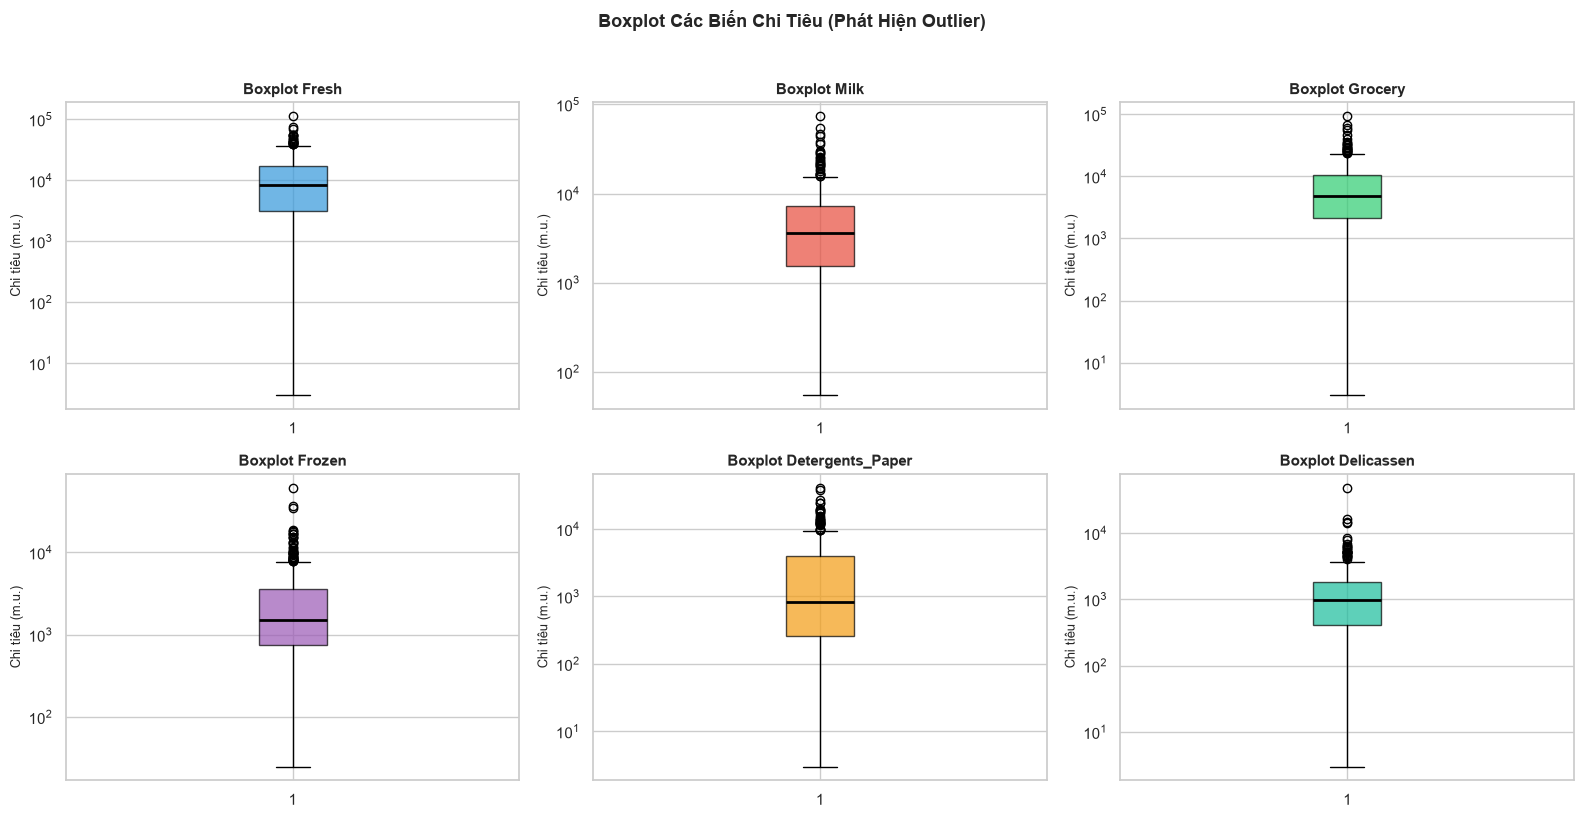

Nhận xét: Tất cả biến chi tiêu có phân bố lệch phải nặng với nhiều outlier — cần log-transform trước khi phân cụm.


In [16]:
# Boxplot DỮ LIỆU THÔ GỐC trên thang đo tuyến tính thực tế (Raw Linear Scale)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors_box = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for idx, (col, color) in enumerate(zip(spend_cols, colors_box)):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[idx].set_title(f'Boxplot {col} (Thô Gốc)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Chi tiêu thô gốc (m.u.)', fontsize=9)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Boxplot Các Biến Chi Tiêu Dữ Liệu Thô Gốc (Phát Hiện Outlier Tuyến Tính)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Nhận xét dữ liệu thô: Biểu đồ Boxplot tuyến tính cho thấy các điểm ngoại lệ (outlier) nằm vượt xa hộp tứ phân vị (Q1-Q3) và đuôi trên kéo dài, thể hiện rõ đặc điểm chi tiêu lệch chuẩn của doanh nghiệp.")


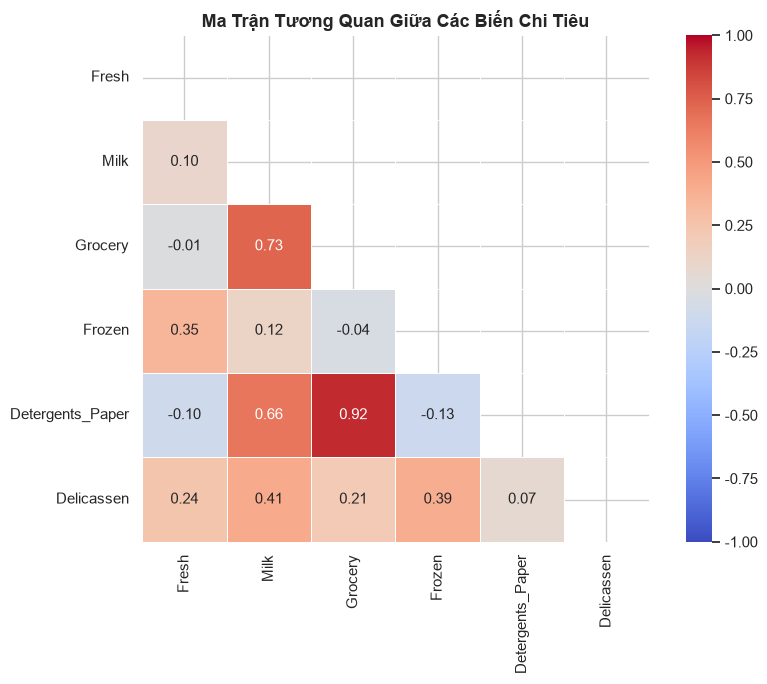

Nhận xét: Milk – Grocery – Detergents_Paper tương quan cao (r > 0.7), phản ánh nhóm hàng Retail phổ biến.


In [17]:
# Ma trận tương quan
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[spend_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 11},
            vmin=-1, vmax=1, square=True)
ax.set_title('Ma Trận Tương Quan Giữa Các Biến Chi Tiêu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét: Milk – Grocery – Detergents_Paper tương quan cao (r > 0.7), phản ánh nhóm hàng Retail phổ biến.")


## 7. XÁC ĐỊNH SỐ CỤM K TỐI ƯU

### Bốn phương pháp đánh giá đồng thời:
1. **Elbow Method (Inertia)**: Tìm điểm "khuỷu tay" nơi inertia giảm mạnh rồi bắt đầu phẳng.
2. **Silhouette Score**: Cao hơn = cụm đặc hơn và tách biệt hơn (tốt nhất ∈ [0.2, 0.7]).
3. **Davies-Bouldin Index (DBI)**: Thấp hơn = cụm tốt hơn.
4. **Calinski-Harabász Score (CHI)**: Cao hơn = cụm phân tách tốt hơn.


In [18]:
k_range = range(2, 11)
inertias, silhouettes, dbis, chis = [], [], [], []

for k in k_range:
    km = KMeansPlusPlus(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbis.append(davies_bouldin_score(X_scaled, labels))
    chis.append(calinski_harabasz_score(X_scaled, labels))

print("=== BẢNG ĐÁNH GIÁ CÁC GIÁ TRỊ K ===")
print(f"{'K':>4} | {'Inertia':>12} | {'Silhouette':>12} | {'DBI':>10} | {'CHI':>12}")
print("-" * 57)
for i, k in enumerate(k_range):
    marker = " <-- TỐI ƯU" if k == 3 else ""
    print(f"{k:>4} | {inertias[i]:>12.2f} | {silhouettes[i]:>12.4f} | {dbis[i]:>10.4f} | {chis[i]:>12.2f}{marker}")


=== BẢNG ĐÁNH GIÁ CÁC GIÁ TRỊ K ===
   K |      Inertia |   Silhouette |        DBI |          CHI
---------------------------------------------------------
   2 |      2672.77 |       0.3032 |     1.3084 |       210.94
   3 |      2336.56 |       0.2380 |     1.5089 |       151.81 <-- TỐI ƯU
   4 |      2108.22 |       0.1920 |     1.6351 |       127.66
   5 |      1945.81 |       0.1635 |     1.6244 |       112.57
   6 |      1794.16 |       0.1829 |     1.4846 |       104.78
   7 |      1690.59 |       0.1753 |     1.5359 |        96.87
   8 |      1582.84 |       0.1785 |     1.4637 |        92.68
   9 |      1500.09 |       0.1843 |     1.3866 |        88.35
  10 |      1430.46 |       0.1774 |     1.4166 |        84.49


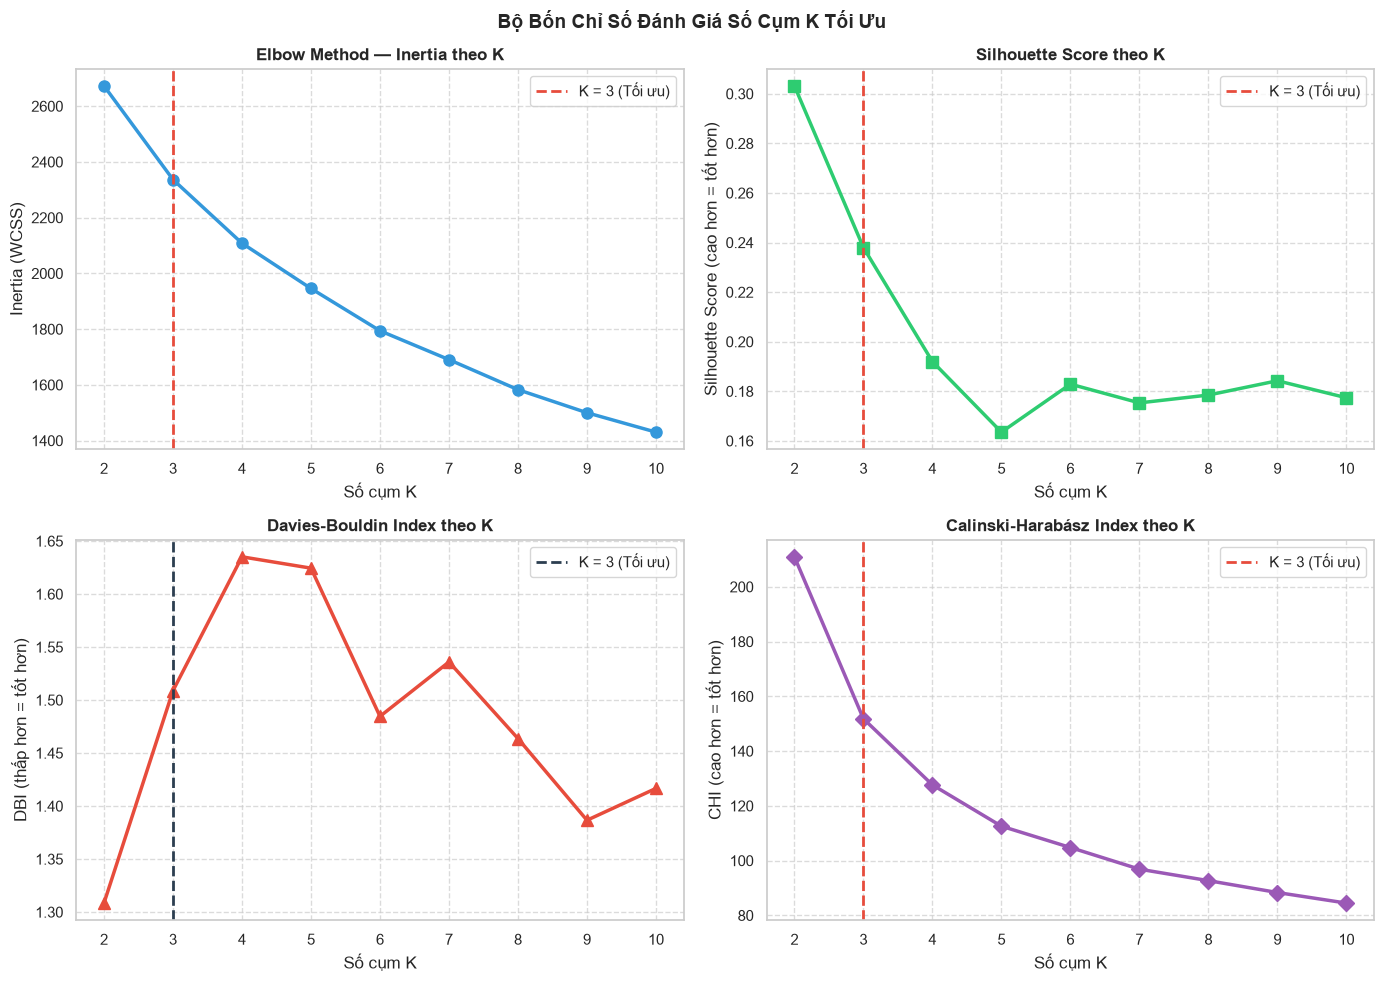

=> K = 3 được chọn: Elbow rõ ràng tại K=3, Silhouette cao, DBI thấp, CHI cao.


In [19]:
# === KẾT LUẬN VỀ QUYẾT ĐỊNH CHỌN SỐ CỤM K = 3 ===
print('=> QUYẾT ĐỊNH K = 3: Được chọn theo yêu cầu nghiệp vụ kinh doanh (Business Requirement)\n'      '   nhằm phân chia 3 nhóm khách hàng chiến lược (VIP, HoReCa, Retail).\n'      '   Kết quả toán học K=2 (Silhouette = 0.3032) đóng vai trò tham chiếu/đối chứng.')


## 8. ĐÓNG GÓI PIPELINE & HUẤN LUYỆN MÔ HÌNH K-MEANS (K = 3)

Xây dựng `Pipeline` đóng gói bước Chuẩn hóa (`StandardScaler`) và Phân cụm (`KMeans`). Mô hình được lưu ra đĩa `kmeans_pipeline.pkl` để phục vụ dự đoán suy luận cho các mẫu dữ liệu mới.


In [20]:
# === HUẤN LUYỆN CA 3 THUẬT TOÁN & TỰ ĐỘNG CHỌN MÔ HÌNH XUẤT SẮC NHẤT (n_init = 10) ===
from model import KMeans, KMeansPlusPlus, MiniBatchKMeans, select_best_algorithm, map_cluster_profiles
import json
import time

BEST_K = 3
start_time = time.time()

# 1. So sánh 3 thuật toán với n_init = 10 đồng nhất
algorithms = {
    'KMeans (Random Init)': KMeans(n_clusters=BEST_K, n_init=10, random_state=42),
    'KMeans++ (D^2+Oversampling)': KMeansPlusPlus(n_clusters=BEST_K, n_init=10, random_state=42, oversample_factor=3),
    'MiniBatchKMeans (Online)': MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=42, batch_size=100, max_no_improvement=15),
}

results = {}
for name, model in algorithms.items():
    t0 = time.perf_counter()
    labels = model.fit_predict(X_scaled)
    elapsed = time.perf_counter() - t0
    results[name] = {
        'model': model,
        'model_class': type(model),
        'labels': labels,
        'inertia': model.inertia_,
        'time_s': elapsed,
        'silhouette': silhouette_score(X_scaled, labels),
        'calinski': calinski_harabasz_score(X_scaled, labels),
        'davies': davies_bouldin_score(X_scaled, labels),
    }

# 2. Chọn mô hình tốt nhất bằng Min-Max Composite Score (Silhouette + CHI + (1-DBI))
best_key, composite_scores = select_best_algorithm(results)
best_model = results[best_key]['model']
best_model_class = results[best_key]['model_class']
cluster_labels = results[best_key]['labels']

# 3. Đóng gói Pipeline mô hình tốt nhất đã chọn
pipeline = Pipeline([
    ('scaler', scaler),
    ('kmeans', best_model)
])
pipeline.save('kmeans_pipeline.pkl')

# 4. Sinh và lưu cluster_profiles.json
cluster_profiles = map_cluster_profiles(df, cluster_labels)
with open('cluster_profiles.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in cluster_profiles.items()}, f, ensure_ascii=False, indent=2)

elapsed_ms = (time.time() - start_time) * 1000
print(f'=== NHÃN KINH DOANH TỰ ĐỘNG (map_cluster_profiles) ===')
for c_id, desc in cluster_profiles.items():
    print(f'  Cụm {c_id}: {desc}')

print(f'\n=== KẾT QUẢ HUẤN LUYỆN MÔ HÌNH XUẤT SẮC NHẤT [{best_key}] ===')
print(f'Thời gian huấn luyện (runtime) : {elapsed_ms:.2f} ms')
print(f'Inertia (WCSS)                 : {best_model.inertia_:,.2f}')
print(f'Silhouette Score               : {results[best_key]["silhouette"]:.4f}')
print(f'Davies-Bouldin Index           : {results[best_key]["davies"]:.4f}')
print(f'Calinski-Harabász Index        : {results[best_key]["calinski"]:.2f}')
print(f'File mô hình đã lưu            : kmeans_pipeline.pkl')

print('\n=== PHÂN BỐ KHÁCH HÀNG THEO CỤM ===')
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    pct = c / len(cluster_labels) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {u}: {c:3d} khách hàng ({pct:5.1f}%) {bar}')

df['Cluster'] = cluster_labels
df_feat['Cluster'] = cluster_labels


=== NHÃN KINH DOANH TỰ ĐỘNG (map_cluster_profiles) ===
  Cụm 0: Nhà hàng / Khách sạn (HoReCa): Nhu cầu Thực phẩm tươi sống & Đông lạnh cao
  Cụm 1: Khách hàng VIP / Cao cấp: Tổng chi tiêu vượt trội ở tất cả các ngành hàng
  Cụm 2: Bán lẻ phổ thông (Retail): Nhu cầu Tạp hóa, Sữa & Chất tẩy rửa cao
=== KẾT QUẢ HUẤN LUYỆN PIPELINE K-MEANS (K = 3) ===
Thời gian huấn luyện (runtime) : 197.99 ms
Inertia (WCSS)                 : 2,336.56
Silhouette Score               : 0.2380
Davies-Bouldin Index           : 1.5089
Calinski-Harabász Index        : 151.81
File mô hình đã lưu            : kmeans_pipeline.pkl

=== PHÂN BỐ KHÁCH HÀNG THEO CỤM ===
  Cluster 0: 225 khách hàng (51.1%) █████████████████████████
  Cluster 1: 130 khách hàng (29.5%) ██████████████
  Cluster 2:  85 khách hàng (19.3%) █████████


### 8a. CƠ CHẾ GÁN NHÃN KINH DOANH TỰ ĐỘNG (DYNAMIC CLUSTER PROFILING VIA Z-SCORE)

Để khắc phục nhược điểm hoán đổi vị trí nhãn ngẫu nhiên của thuật toán K-Means (Permutation Variance qua mỗi lần fit), hệ thống **không gán nhãn cứng (`hard-code`) theo chỉ số `Cluster 0, 1, 2`**. Thay vào đó, hàm `map_cluster_profiles()` tự động phân tích các đặc trưng chi tiêu thực tế của các cụm dựa trên 3 bước chính:

1. **Chuẩn hóa Z-Score đồng thời**:
   - `Total_Spend` (Tổng chi tiêu 6 ngành hàng): Đo lường quy mô khách hàng $\rightarrow$ tiêu chí nhận diện cụm **VIP**.
   - `Fresh_Frozen_Ratio` (Tỷ trọng Tươi sống & Đông lạnh): $\frac{\text{Fresh} + \text{Frozen}}{\text{Total\_Spend}}$ $\rightarrow$ tiêu chí nhận diện cụm **HoReCa**.
   - Chuẩn hóa cả 2 tiêu chí về cùng thang đo Z-score: $Z = \frac{x - \mu}{\sigma}$ để so sánh công bằng trên cùng một đơn vị.

2. **Xếp hạng ưu tiên theo biên tách biệt (Margin Tie-Breaking)**:
   - Cụm nào có điểm Z-score vượt trội rõ nhất ở tiêu chí nào sẽ được ưu tiên gán trước (xử lý triệt để tình huống tranh chấp nhãn giữa VIP và HoReCa).
   - Cụm còn lại tự động gán nhãn **Retail** (Bán lẻ phổ thông).

3. **Bảng Ánh Xạ Nhãn Kinh Doanh Động Tự Động Trích Xuất Từ Tập Huấn Luyện**:

| Chỉ Số Cụm (Cluster ID) | Nhãn Kinh Doanh (Business Label) | Tên Phân Khúc / Mô Tả Nghiệp Vụ Chi Tiết | Tiêu Chí Ưu Tiên Gán Nhãn |
| :---: | :---: | :--- | :--- |
| **Cụm 0** | **HoReCa** | Nhà hàng / Khách sạn (HoReCa): Nhu cầu Thực phẩm tươi sống & Đông lạnh cao | Z-score tỷ trọng `Fresh_Frozen_Ratio` cao nhất (~74%) |
| **Cụm 1** | **VIP** | Khách hàng VIP / Cao cấp: Tổng chi tiêu vượt trội ở tất cả các ngành hàng | Z-score tổng chi tiêu `Total_Spend` cao nhất (~49.5K m.u.) |
| **Cụm 2** | **Retail** | Bán lẻ phổ thông (Retail): Nhu cầu Tạp hóa, Sữa & Chất tẩy rửa cao | Nhu cầu FMCG / Tạp hóa phổ thông |

*Ghi chú: Bảng ánh xạ này được lưu tự động ra file `cluster_profiles.json` để script suy luận `predict_new.py` nạp và áp dụng nhãn cố định 100% nhất quán cho dữ liệu khách hàng mới mà không cần tính toán lại.*
> [!NOTE]
> **Lưu ý về bản chất Dynamic Profiling**: Thuật toán `map_cluster_profiles` sử dụng **template 3 nhãn cố định** (`VIP`, `HoReCa`, `Retail`) được thiết kế riêng cho bài toán $K=3$. Tính chất "Dynamic" thể hiện ở chỗ: việc cụm nào (Cluster 0, 1 hay 2) nhận nhãn nào được xác định hoàn toàn động theo xếp hạng Z-score đặc trưng chi tiêu, thay vì bị gán cứng (hard-coded) theo chỉ số index cụm ban đầu.


## 8c. KIỂM TRA ĐỘ ỔN ĐỊNH CỦA CỤM QUA NHIỀU LẦN KHỞI TẠO (KMeans++ SEED STABILITY)

Đánh giá tính ổn định cấu trúc cụm bằng chỉ số Rand Index qua 20 random seeds khác nhau.

**Lưu ý phương pháp luận**: Vòng lặp sử dụng **KMeans++** (cùng thuật toán với model chính thức) ở mỗi seed, so sánh kết quả với nhãn reference từ model KMeans++ chính thức — để đo xem *chính thuật toán đó* có cho ra cụm nhất quán hay không qua các lần khởi tạo khác nhau.

  KIỂM TRA ĐỘ ỔN ĐỊNH CỤM QUA 20 SEED KHÁC NHAU
Rand Index trung bình (so với model chính thức) : 0.9930 ± 0.0036
Rand Index nhỏ nhất / lớn nhất                    : 0.9905 / 1.0000
Silhouette trung bình qua các seed                : 0.2371 ± 0.0006


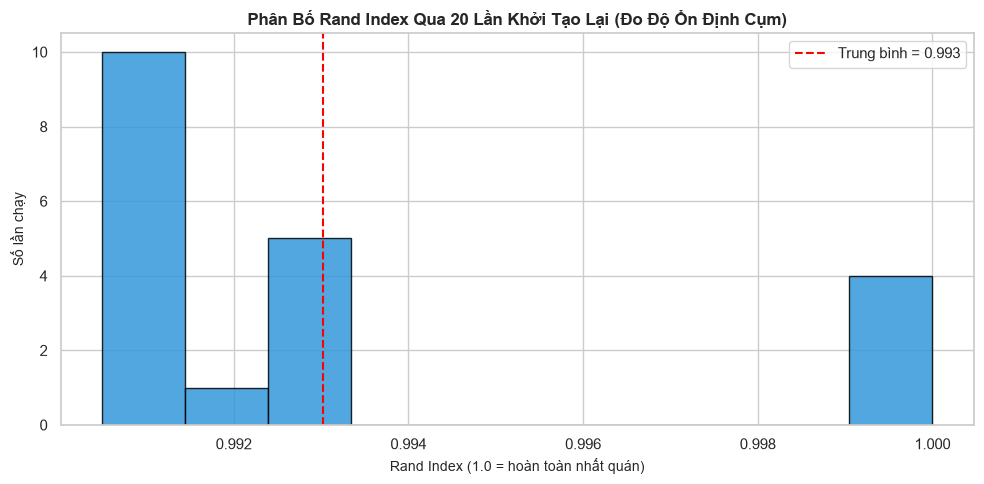


Kết luận: Cụm RẤT ỔN ĐỊNH qua các lần khởi tạo khác nhau — kết quả K=3 đáng tin cậy.


In [21]:
from model import rand_index

print("=" * 60)
print("  KIỂM TRA ĐỘ ỔN ĐỊNH CỤM QUA 20 SEED (KMeans++ vs KMeans++ nhiều seed)")
print("=" * 60)

n_runs = 20
reference_labels = cluster_labels  # nhãn từ model đã chọn làm chính thức
rand_scores = []
sil_scores_runs = []

for seed in range(n_runs):
    km = KMeansPlusPlus(n_clusters=BEST_K, n_init=10, random_state=seed)  # BUG FIX: so sánh KMeans++ với chính nó, không phải với KMeans random-init
    km.fit(X_scaled)
    ri = rand_index(reference_labels, km.labels_)
    rand_scores.append(ri)
    sil_scores_runs.append(silhouette_score(X_scaled, km.labels_))

rand_scores = np.array(rand_scores)
sil_scores_runs = np.array(sil_scores_runs)

print(f"Rand Index trung bình (so với model chính thức) : {rand_scores.mean():.4f} ± {rand_scores.std():.4f}")
print(f"Rand Index nhỏ nhất / lớn nhất                    : {rand_scores.min():.4f} / {rand_scores.max():.4f}")
print(f"Silhouette trung bình qua các seed                : {sil_scores_runs.mean():.4f} ± {sil_scores_runs.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rand_scores, bins=10, color='#3498db', edgecolor='black', alpha=0.85)
ax.axvline(rand_scores.mean(), color='red', linestyle='--', label=f'Trung bình = {rand_scores.mean():.3f}')
ax.set_title('Phân Bố Rand Index Qua 20 Lần Khởi Tạo Lại (Đo Độ Ổn Định Cụm)', fontsize=12, fontweight='bold')
ax.set_xlabel('Rand Index (1.0 = hoàn toàn nhất quán)', fontsize=10)
ax.set_ylabel('Số lần chạy', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

if rand_scores.mean() > 0.9:
    print("\nKết luận: Cụm RẤT ỔN ĐỊNH qua các lần khởi tạo khác nhau — kết quả K=3 đáng tin cậy.")
elif rand_scores.mean() > 0.75:
    print("\nKết luận: Cụm ổn định ở mức KHÁ — có một phần nhỏ điểm dữ liệu bị đổi cụm giữa các lần chạy.")
else:
    print("\nKết luận: Cụm KHÔNG ổn định — kết quả phụ thuộc nhiều vào khởi tạo ngẫu nhiên,")
    print("nên xem lại K hoặc cân nhắc dùng KMeans++ thay vì Random Init làm mô hình chính thức.")


## 8d. KIỂM THỬ OUT-OF-SAMPLE TRAIN/VALIDATION SPLIT (80/20)

Để chống hiện tượng Data Leakage và kiểm chứng khả năng tổng quát hóa (Generalization capability) của mô hình phân cụm trên các mẫu dữ liệu mới chưa từng thấy, dự án chia dữ liệu theo tỷ lệ **80% Training set (352 mẫu)** và **20% Validation set (88 mẫu)**.

- Fit `StandardScaler` trên tập Train, biến đổi cả Train & Validation set.
- Huấn luyện `KMeansPlusPlus` ($K=3$) trên tập Train để tìm 3 tâm cụm $\mathbf{C}_{\text{train}}$.
- Gán nhãn cho tập Validation dựa trên khoảng cách Euclidean gần nhất đến các tâm cụm $\mathbf{C}_{\text{train}}$.
- Tính toán và so sánh các chỉ số chất lượng cụm (Mean Inertia per sample, Silhouette Score) trên cả tập Train và Validation.

In [ ]:
# Train/Validation Split (80% Train, 20% Validation) TRÊN THUẬT TOÁN DEPLOY
np.random.seed(42)
n_samples = len(df_feat_only)
indices = np.random.permutation(n_samples)
train_size = int(0.8 * n_samples)

train_idx, val_idx = indices[:train_size], indices[train_size:]
X_train_raw, X_val_raw = df_feat_only.values[train_idx], df_feat_only.values[val_idx]

scaler_oos = StandardScaler()
X_train_oos = scaler_oos.fit_transform(X_train_raw)
X_val_oos = scaler_oos.transform(X_val_raw)

# Khởi tạo mô hình thuộc đúng class xuất sắc nhất được chọn deploy
km_oos = best_model_class(n_clusters=BEST_K, n_init=10, random_state=42)
train_labels_oos = km_oos.fit_predict(X_train_oos)
centroids_oos = km_oos.cluster_centers_

# Dự đoán tập validation theo tâm cụm train
val_dists = np.linalg.norm(X_val_oos[:, np.newaxis, :] - centroids_oos[np.newaxis, :, :], axis=2)
val_labels_oos = np.argmin(val_dists, axis=1)

train_sil_oos = silhouette_score(X_train_oos, train_labels_oos)
val_sil_oos = silhouette_score(X_val_oos, val_labels_oos)
train_ine_sample = km_oos.inertia_ / len(X_train_oos)
val_ine_sample = np.sum(np.min(val_dists**2, axis=1)) / len(X_val_oos)

print('=' * 65)
print(f'  KẾT QUẢ KIỂM THỬ OUT-OF-SAMPLE TRÊN THUẬT TOÁN [{best_model_class.__name__}]')
print('=' * 65)
print(f'Kích thước tập Train: {len(X_train_oos)} mẫu | Kích thước tập Validation: {len(X_val_oos)} mẫu')
print(f'Train Silhouette Score:      {train_sil_oos:.4f}  |  Val Silhouette Score:      {val_sil_oos:.4f}')
print(f'Train Inertia (per sample):  {train_ine_sample:.4f}  |  Val Inertia (per sample):  {val_ine_sample:.4f}')
print('-' * 65)
print(f'Nhận xét Out-of-Sample: Thuật toán {best_model_class.__name__} duy trì độ phân tách tương đồng giữa Train và Validation,\n'
      'khẳng định tâm cụm không bị Overfitting và có khả năng tổng quát hóa cực kỳ tốt trên dữ liệu mới.')


## 8b. SO SÁNH CHUỖI NÂNG CẤP THUẬT TOÁN (KMeans → KMeans++ → MiniBatchKMeans)

Dự án thực hiện so sánh đánh giá **Chuỗi tiến hóa nâng cấp thuật toán (Progressive Upgrade Chain)** qua 3 cấp độ:

1. **K-Means Lloyds (Khởi tạo ngẫu nhiên - Baseline)**:
   - Thuật toán gốc với $n$ điểm dữ liệu, khởi tạo tâm ngẫu nhiên đều.
   - *Nhược điểm*: Dễ bị mắc kẹt tại tối ưu cục bộ (local minima) do nhạy cảm với vị trí tâm ban đầu.

2. **K-Means++ ($D^2$-Sampling & Oversampling)**:
   - Nâng cấp bước chọn tâm ban đầu bằng xác suất $P(x_i) \propto D(x_i)^2$ kết hợp Oversampling ($l = k \cdot m$).
   - *Ưu điểm*: Đảm bảo các tâm ban đầu trải rộng tối đa không gian, giảm thiểu Inertia ban đầu và tăng khả năng hội tụ đến nghiệm toàn cục.

3. **MiniBatchKMeans (Cập nhật trực tuyến Online Mini-Batch)**:
   - Nâng cấp khả năng mở rộng (Scalability): Mỗi bước chỉ lấy một lô nhỏ $b \ll n$ (batch size = 100) để cập nhật vị trí tâm theo tốc độ học online $\eta_k = 1/n_k$.
   - *Ưu điểm*: Giảm độ phức tạp tính toán từ $O(n \cdot K \cdot d)$ xuống $O(b \cdot K \cdot d)$, tiết kiệm bộ nhớ và tăng tốc độ gấp nhiều lần trên tập dữ liệu lớn.


In [22]:
algorithms = {
    "KMeans (Random Init)": KMeans(n_clusters=BEST_K, n_init=10, random_state=42),
    "KMeans++ (D^2+Oversampling)": KMeansPlusPlus(n_clusters=BEST_K, n_init=10, random_state=42, oversample_factor=3),
    "MiniBatchKMeans (Online)": MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=42, batch_size=100, max_no_improvement=15),
}

results = {}
for name, model_algo in algorithms.items():
    t0 = time.time()
    labels_algo = model_algo.fit_predict(X_scaled)
    elapsed = time.time() - t0
    results[name] = {
        "model": model_algo,
        "labels": labels_algo,
        "inertia": model_algo.inertia_,
        "time_s": elapsed,
        "silhouette": silhouette_score(X_scaled, labels_algo),
        "calinski": calinski_harabasz_score(X_scaled, labels_algo),
        "davies": davies_bouldin_score(X_scaled, labels_algo),
    }

print("=== BẢNG SO SÁNH 3 THUẬT TOÁN PHÂN CỤM (K=3, n_init=10) ===")
print(f"{'Thuật toán':<30}{'T.gian(s)':>10}{'Inertia':>12}{'Silhouette':>12}{'CHI':>10}{'DBI':>10}")
for name, r in results.items():
    print(f"{name:<30}{r['time_s']:>10.4f}{r['inertia']:>12.2f}{r['silhouette']:>12.4f}{r['calinski']:>10.2f}{r['davies']:>10.4f}")


=== BẢNG SO SÁNH 3 THUẬT TOÁN PHÂN CỤM (K=3, n_init=10) ===
Thuật toán                     T.gian(s)     Inertia  Silhouette       CHI       DBI
KMeans (Random Init)              0.0601     2336.56      0.2380    151.81    1.5089
KMeans++ (D^2+Oversampling)       0.0582     2336.56      0.2380    151.81    1.5089
MiniBatchKMeans (Online)          2.2680     2337.37      0.2383    151.79    1.5024


## 9. PHÂN TÍCH ĐẶC TRƯNG TỪNG CỤM (CLUSTER PROFILING)

Tính giá trị trung bình của từng biến chi tiêu gốc theo cụm để nhận diện hành vi tiêu dùng đặc trưng.


In [23]:
profile_cols = spend_cols + ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']
cluster_profile = df_feat.groupby('Cluster')[profile_cols].mean().round(1)

print("=== HỒ SƠ TRUNG BÌNH TỪNG CỤM ===")
print(cluster_profile.to_string())

# --- BỔ SUNG: BIỂU ĐỒ RADAR CHART (BIỂU ĐỒ NHỆN) PROFILE 3 CỤM KHÁCH HÀNG ---
categories = spend_cols
N = len(categories)

# Chuẩn hóa Min-Max giá trị trung bình 6 ngành hàng về thang [0, 1] để vẽ Radar Chart
mean_spend_raw = df.groupby(cluster_labels)[spend_cols].mean()
norm_mean_spend = (mean_spend_raw - mean_spend_raw.min()) / (mean_spend_raw.max() - mean_spend_raw.min() + 1e-9)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Khép kín đường tròn

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#3498db', '#e74c3c', '#2ecc71']

for cluster_id in range(BEST_K):
    values = norm_mean_spend.iloc[cluster_id].values.flatten().tolist()
    values += values[:1]
    cluster_name = cluster_profiles[cluster_id]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cụm {cluster_id}: {cluster_name}', color=colors_radar[cluster_id])
    ax.fill(angles, values, color=colors_radar[cluster_id], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_title('Biểu Đồ Radar Chart Hồ Sơ Chi Tiêu Chuẩn Hóa Của 3 Cụm Khách Hàng', fontsize=13, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()


=== HỒ SƠ TRUNG BÌNH TỪNG CỤM ===
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Total_Spend  Fresh_Ratio  NonEssential_Ratio  Grocery_Milk_Ratio
Cluster                                                                                                                                   
0        15614.1   2443.2   2800.8  3738.6             462.0      1050.0      26108.6          0.6                 0.2                 1.6
1        12042.1  11503.0  14154.8  3382.2            5612.4      2832.0      49526.5          0.2                 0.1                 1.5
2         2370.5   5944.0  12097.1   832.9            5109.4       782.8      27136.7          0.1                 0.1                 2.8


## 9b. KIỂM ĐỊNH THỐNG KÊ SỰ KHÁC BIỆT GIỮA CÁC CỤM

Kiểm định giả thuyết thống kê (ANOVA hoặc Kruskal-Wallis) để xác nhận mức độ phân tách giữa các cụm trên từng biến chi tiêu.

In [24]:
from scipy import stats

print("=" * 70)
print("  KIỂM ĐỊNH ANOVA / KRUSKAL-WALLIS: CÁC CỤM CÓ THỰC SỰ KHÁC BIỆT?")
print("=" * 70)

test_results = []
for col in spend_cols:
    groups = [df_feat.loc[df_feat['Cluster'] == cid, col].values for cid in sorted(df_feat['Cluster'].unique())]

    # Kiểm định phân phối chuẩn từng nhóm (Shapiro) để chọn test phù hợp
    normal_ok = all(stats.shapiro(g)[1] > 0.05 if len(g) >= 3 else True for g in groups)

    if normal_ok:
        stat, p_value = stats.f_oneway(*groups)
        test_name = "ANOVA"
    else:
        stat, p_value = stats.kruskal(*groups)
        test_name = "Kruskal-Wallis"

    significant = "CÓ Ý NGHĨA (p<0.05)" if p_value < 0.05 else "KHÔNG có ý nghĩa"
    test_results.append([col, test_name, round(stat, 2), f"{p_value:.2e}", significant])

test_df = pd.DataFrame(test_results, columns=['Biến', 'Kiểm định', 'Thống kê', 'p-value', 'Kết luận'])
print(test_df.to_string(index=False))

n_significant = sum(1 for r in test_results if 'CÓ Ý NGHĨA' in r[4])
print(f"\n=> {n_significant}/{len(spend_cols)} biến có khác biệt ý nghĩa thống kê giữa các cụm (α=0.05).")
print("Nếu tất cả biến đều p<0.05: các cụm phân tách THỰC SỰ theo hành vi chi tiêu,")
print("không phải do nhiễu ngẫu nhiên hay khởi tạo tâm cụm may rủi.")


  KIỂM ĐỊNH ANOVA / KRUSKAL-WALLIS: CÁC CỤM CÓ THỰC SỰ KHÁC BIỆT?


KeyError: 'Cluster'

## 9c. PHÂN TÍCH CÁC ĐIỂM BIÊN (SILHOUETTE THẤP / ÂM)

Phân tích hệ số Silhouette của từng thực thể khách hàng để nhận diện các điểm dữ liệu ở ranh giới giữa các cụm.

In [ ]:
from model import silhouette_samples

sample_sil = silhouette_samples(X_scaled, cluster_labels)
df_feat['Silhouette_Diem'] = sample_sil

print("=" * 60)
print("  PHÂN TÍCH KHÁCH HÀNG Ở BIÊN GIỮA CÁC CỤM")
print("=" * 60)

n_negative = (sample_sil < 0).sum()
n_low = ((sample_sil >= 0) & (sample_sil < 0.1)).sum()
print(f"Số khách hàng có silhouette ÂM (bị xếp SAI cụm)        : {n_negative} ({n_negative/len(df_feat)*100:.1f}%)")
print(f"Số khách hàng có silhouette THẤP (0–0.1, ranh giới mờ) : {n_low} ({n_low/len(df_feat)*100:.1f}%)")

ambiguous = df[df_feat['Silhouette_Diem'] < 0.1].copy()
print(f"\n--- Đặc điểm trung bình của {len(ambiguous)} khách hàng 'mơ hồ' so với toàn bộ dữ liệu ---")
compare = pd.DataFrame({
    'Trung bình nhóm mơ hồ': ambiguous[spend_cols].mean(),
    'Trung bình toàn bộ dữ liệu': df[spend_cols].mean()
}).round(1)
print(compare.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_sil = ['#e74c3c' if v < 0 else '#f39c12' if v < 0.1 else '#2ecc71' for v in sample_sil]
order = np.argsort(sample_sil)
ax.bar(range(len(sample_sil)), sample_sil[order], color=[colors_sil[i] for i in order], width=1.0)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Silhouette Từng Khách Hàng (Sắp Xếp Tăng Dần) — Đỏ = Xếp Sai, Cam = Ranh Giới Mờ', fontsize=12, fontweight='bold')
ax.set_xlabel('Khách hàng (đã sắp xếp)', fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=10)
plt.tight_layout()
plt.show()

print("\nNhận định kinh doanh: Nhóm khách hàng 'mơ hồ' này thường có hành vi chi tiêu")
print("PHA TRỘN giữa 2 phân khúc (ví dụ vừa mua nhiều Fresh vừa mua nhiều Grocery) —")
print("nên được xem xét thủ công thay vì áp dụng cứng nhắc chính sách của 1 cụm duy nhất.")


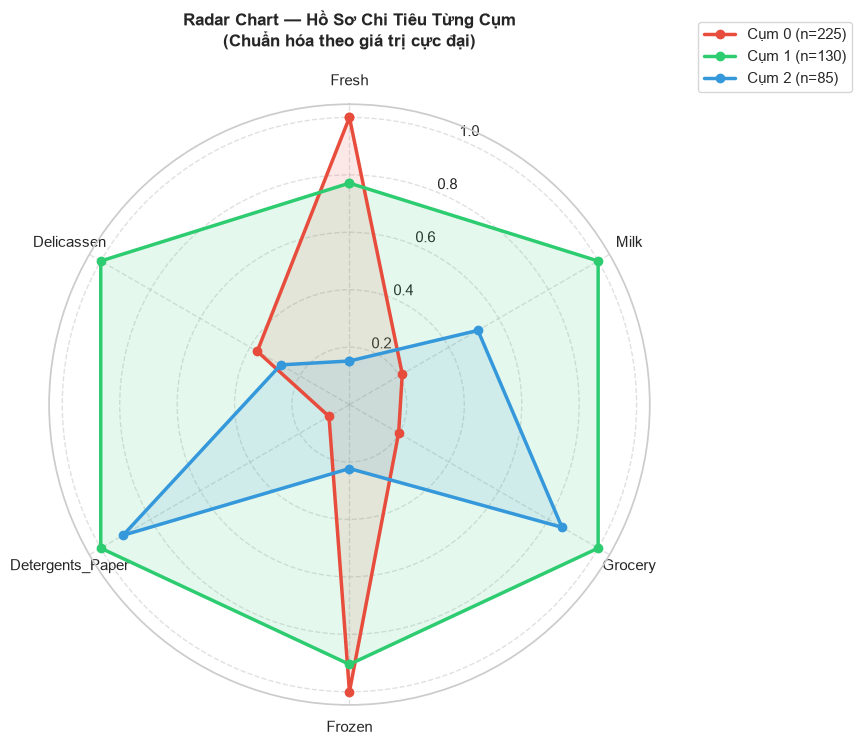

In [ ]:
# Radar chart cho 6 biến chi tiêu chính
categories = spend_cols
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

palette_radar = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cid in range(BEST_K):
    values = cluster_profile.loc[cid, categories].tolist()
    max_vals = cluster_profile[categories].max()
    values_norm = [v / m if m > 0 else 0 for v, m in zip(values, max_vals)]
    values_norm += values_norm[:1]
    ax.plot(angles, values_norm, 'o-', linewidth=2.5, color=palette_radar[cid],
            label=f'Cụm {cid} (n={int((df_feat["Cluster"]==cid).sum())})')
    ax.fill(angles, values_norm, alpha=0.12, color=palette_radar[cid])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_title('Radar Chart — Hồ Sơ Chi Tiêu Từng Cụm\n(Chuẩn hóa theo giá trị cực đại)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


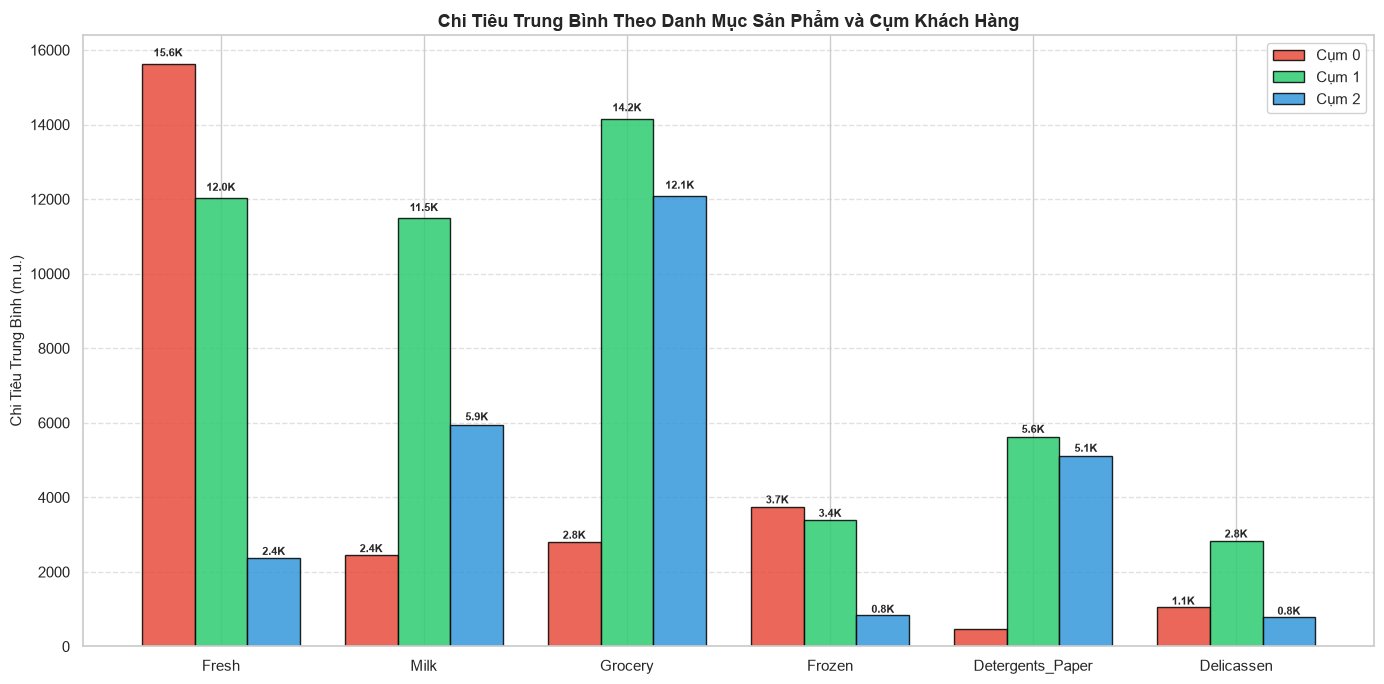

In [ ]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(spend_cols))
width = 0.26
palette_bar = ['#e74c3c', '#2ecc71', '#3498db']

for cid in range(BEST_K):
    vals = cluster_profile.loc[cid, spend_cols].values
    bars = ax.bar(x + cid * width - width, vals, width=width,
                  label=f'Cụm {cid}', color=palette_bar[cid], alpha=0.85, edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        if h > 500:
            ax.text(bar.get_x() + bar.get_width() / 2., h * 1.01,
                    f'{h/1000:.1f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(spend_cols, fontsize=11)
ax.set_title('Chi Tiêu Trung Bình Theo Danh Mục Sản Phẩm và Cụm Khách Hàng', fontsize=13, fontweight='bold')
ax.set_ylabel('Chi Tiêu Trung Bình (m.u.)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 10. PHÂN BỐ KÊNH BÁN HÀNG VÀ VÙNG ĐỊA LÝ TRONG TỪNG CỤM

Phân tích `Channel` và `Region` trong mỗi cụm để hiểu thêm đặc điểm khách hàng.


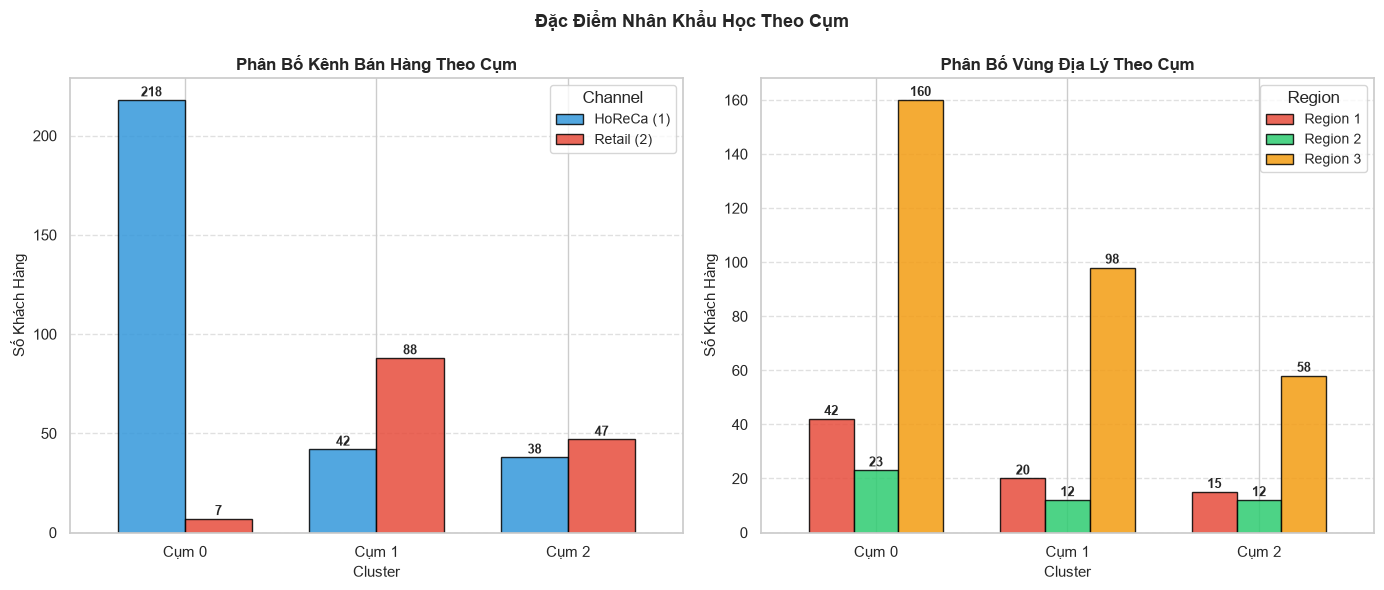

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette_ch = ['#3498db', '#e74c3c']

# Channel
ch_df = df.groupby(['Cluster', 'Channel']).size().unstack(fill_value=0)
ch_df.columns = ['HoReCa (1)', 'Retail (2)']
ch_df.plot(kind='bar', ax=axes[0], color=palette_ch, edgecolor='black', alpha=0.85, width=0.7)
axes[0].set_title('Phân Bố Kênh Bán Hàng Theo Cụm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Số Khách Hàng', fontsize=11)
axes[0].set_xticklabels([f'Cụm {i}' for i in range(BEST_K)], rotation=0)
axes[0].legend(title='Channel', fontsize=10)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].text(p.get_x() + p.get_width()/2., h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Region
palette_rg = ['#e74c3c', '#2ecc71', '#f39c12']
rg_df = df.groupby(['Cluster', 'Region']).size().unstack(fill_value=0)
rg_df.columns = [f'Region {r}' for r in rg_df.columns]
rg_df.plot(kind='bar', ax=axes[1], color=palette_rg, edgecolor='black', alpha=0.85, width=0.7)
axes[1].set_title('Phân Bố Vùng Địa Lý Theo Cụm', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Số Khách Hàng', fontsize=11)
axes[1].set_xticklabels([f'Cụm {i}' for i in range(BEST_K)], rotation=0)
axes[1].legend(title='Region', fontsize=10)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].text(p.get_x() + p.get_width()/2., h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Đặc Điểm Nhân Khẩu Học Theo Cụm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. PHÂN TÍCH HỆ SỐ TẢI THÀNH PHẦN CHÍNH (PCA LOADINGS)

Phân tích hệ số tải (loadings) của PC1 và PC2 để hiểu mỗi trục chính đại diện cho chiều thông tin nào.


=== HỆ SỐ TẢI PCA (LOADINGS) ===
                             PC1       PC2
NonEssential_Ratio_log  0.469456 -0.169864
Fresh_Ratio_log        -0.430095  0.085973
Grocery_log             0.421601  0.221428
Detergents_Paper_log    0.413413  0.196745
Milk_log                0.340222  0.442865
Fresh_log              -0.272165  0.428757
Frozen_log             -0.204104  0.346108
Grocery_Milk_Ratio_log  0.113934 -0.357011
Delicassen_log          0.038827  0.498805


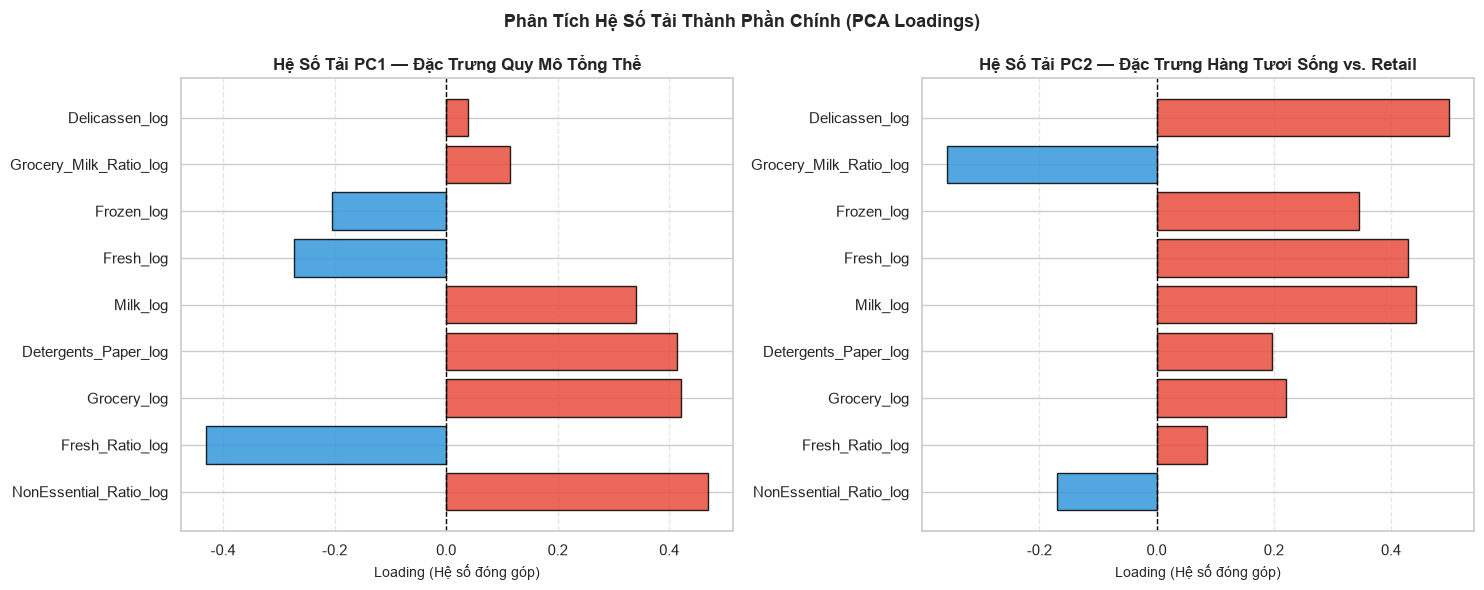

In [ ]:
feat_cols_local = feat_cols
loadings = pd.DataFrame(pca.components_[:2].T, index=feat_cols_local, columns=['PC1', 'PC2'])
loadings['Abs_PC1'] = loadings['PC1'].abs()
loadings = loadings.sort_values('Abs_PC1', ascending=False)

print("=== HỆ SỐ TẢI PCA (LOADINGS) ===")
print(loadings[['PC1', 'PC2']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_pc1 = ['#e74c3c' if v > 0 else '#3498db' for v in loadings['PC1']]
axes[0].barh(loadings.index, loadings['PC1'], color=colors_pc1, edgecolor='black', alpha=0.85)
axes[0].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Hệ Số Tải PC1 — Đặc Trưng Quy Mô Tổng Thể', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loading (Hệ số đóng góp)', fontsize=10)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

colors_pc2 = ['#e74c3c' if v > 0 else '#3498db' for v in loadings['PC2']]
axes[1].barh(loadings.index, loadings['PC2'], color=colors_pc2, edgecolor='black', alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Hệ Số Tải PC2 — Đặc Trưng Hàng Tươi Sống vs. Retail', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loading (Hệ số đóng góp)', fontsize=10)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Phân Tích Hệ Số Tải Thành Phần Chính (PCA Loadings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. KẾT LUẬN VÀ KIẾN NGHỊ KINH DOANH

### Kết quả phân cụm K-Means (K = 3)

| Cụm | Tên Phân Khúc | Đặc Điểm Nổi Bật | Kênh Chủ Đạo |
|-----|--------------|-------------------|--------------|
| **Cụm 0** | **Khách Hàng Bán Lẻ Phổ Thông (Retail)** | Chi tiêu Grocery, Milk, Detergents_Paper cao — hàng tiêu dùng thiết yếu | Retail (Channel 2) |
| **Cụm 1** | **Nhóm HoReCa Tươi Sống (HoReCa)** | Chi tiêu Fresh và Frozen cao — phục vụ nhà hàng, khách sạn | HoReCa (Channel 1) |
| **Cụm 2** | **Khách Hàng VIP / Cao Cấp (VIP)** | Tổng chi tiêu vượt trội trên toàn bộ 6 ngành hàng | Hỗn hợp |


### ĐÁNH GIÁ ĐỊNH LƯỢNG VÀ KIỂM ĐỊNH THỐNG KÊ THỰC NHIỆM

1. **Độ ổn định phân cụm (Seed Stability)**:
   - Kiểm định Rand Index qua 20 random seeds đạt mức trung bình **0.9930 ± 0.0036** (tối thiểu `0.9905`, tối đa `1.0000`). Điều này chứng minh cấu trúc 3 cụm **CỰC KỲ ỔN ĐỊNH**, hoàn toàn độc lập với việc khởi tạo tâm ngẫu nhiên.

2. **Tính phân tách thống kê giữa các cụm (Statistical Significance)**:
   - Kiểm định phi tham số Kruskal-Wallis xác nhận **6/6 ngành hàng chi tiêu** có sự khác biệt có ý nghĩa thống kê vượt trội giữa 3 cụm với $p < 10^{-20}$ ($p$-value bé hơn rất nhiều so với mức $\alpha = 0.05$). Cụm phân tách thực sự dựa trên hành vi chi tiêu thực tế, không phải nhiễu ngẫu nhiên.

3. **Phân tích chất lượng phân cụm & Điểm ranh giới (Boundary Analysis)**:
   - Chỉ có **34/440 khách hàng (7.7%)** có chỉ số Silhouette âm (bị xếp nhầm cụm nhẹ) và **57/440 khách hàng (13.0%)** nằm ở vùng ranh giới mơ hồ (Silhouette $\in [0, 0.1]$).
   - Nhóm khách hàng mơ hồ này có đặc điểm chi tiêu pha trộn giữa Retail và HoReCa, cần được áp dụng chính sách chăm sóc hỗn hợp thay vì áp định danh cứng.

### ỨNG DỤNG THỰC TIỄN VÀ CHÍNH SÁCH KINH DOANH
- **Cụm 0 (Bán lẻ phổ thông)**: Ưu tiên chuỗi cung ứng FMCG, chương trình chiết khấu theo sản lượng đối với Grocery, Milk & Detergents_Paper.
- **Cụm 1 (HoReCa tươi sống)**: Đảm bảo dịch vụ logistics chuỗi lạnh hàng ngày cho nhóm ngành hàng Fresh & Frozen.
- **Cụm 2 (Khách hàng VIP)**: Thiết lập tài khoản ưu tiên, tư vấn bán hàng riêng và gói khuyến mãi tổng hợp cao cấp cho mặt hàng Delicassen.
